<a href="https://colab.research.google.com/github/Yu-Zilin/Bankrupcy-Prediction/blob/main/Bankrupcy_Prediction_with_Log_Transformation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
fedesoriano_company_bankruptcy_prediction_path = kagglehub.dataset_download('fedesoriano/company-bankruptcy-prediction')

print('Data source import complete.')


Data source import complete.


## 0. Notebook Setup

In [36]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/company-bankruptcy-prediction/data.csv


In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

from sklearn.metrics import make_scorer
from sklearn.metrics import fbeta_score
from sklearn.metrics import matthews_corrcoef

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

import warnings
warnings.filterwarnings("ignore")

datafile="/kaggle/input/company-bankruptcy-prediction/data.csv"

## 1. Data inspection

In [38]:
rawdata=pd.read_csv(datafile)
rawdata

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,0,0.493687,0.539468,0.543230,0.604455,0.604462,0.998992,0.797409,0.809331,0.303510,...,0.799927,0.000466,0.623620,0.604455,0.840359,0.279606,0.027064,0.566193,1,0.029890
6815,0,0.475162,0.538269,0.524172,0.598308,0.598308,0.998992,0.797414,0.809327,0.303520,...,0.799748,0.001959,0.623931,0.598306,0.840306,0.278132,0.027009,0.566018,1,0.038284
6816,0,0.472725,0.533744,0.520638,0.610444,0.610213,0.998984,0.797401,0.809317,0.303512,...,0.797778,0.002840,0.624156,0.610441,0.840138,0.275789,0.026791,0.565158,1,0.097649
6817,0,0.506264,0.559911,0.554045,0.607850,0.607850,0.999074,0.797500,0.809399,0.303498,...,0.811808,0.002837,0.623957,0.607846,0.841084,0.277547,0.026822,0.565302,1,0.044009


In [39]:
rawdata.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


## 2. Data cleaning

### 2.1 Undersampling

Despite being a huge dataset, it's very imbalanced.

In [40]:
counts=rawdata.groupby("Bankrupt?")["Bankrupt?"].count()
counts

,Bankrupt?
Bankrupt?,
0,6599
1,220


This will make the positive bankrupt cases more difficult to identify. To deal with it, undersampling is applied to the dataset: All the positives are preserved and most of the negatives are dropped so we can set the fraction of positives of the new balanced dataset. In this case, we set the positive fraction to 40%.

In [41]:
def undersample(data, class_column, minor_class_frac):
    counter=data.groupby(class_column)[class_column].count()
    minor_class=counter[counter==counter.min()].index[0]
    major_class=counter[counter==counter.max()].index[0]

    minor_class_data=data[data[class_column]==minor_class]
    major_class_data=data[data[class_column]==major_class]

    ratio=counter[minor_class]/counter[major_class]

    major_class_undersampling=(1./minor_class_frac - 1.)*ratio

    major_class_data=major_class_data.sample(frac=major_class_undersampling)

    newdata=pd.concat([minor_class_data,major_class_data])

    return newdata

balancedata=undersample(rawdata,"Bankrupt?", minor_class_frac=0.4)
discardata=pd.concat([rawdata,balancedata]).drop_duplicates(keep=False)

balancedata.groupby("Bankrupt?")["Bankrupt?"].count()

,Bankrupt?
Bankrupt?,
0,330
1,220


In [42]:
balancedata

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
746,0,0.568469,0.608864,0.601317,0.603252,0.603309,0.999007,0.797651,0.809490,0.303901,...,0.835170,0.001344,0.623755,0.603253,0.843472,0.280676,0.026803,0.565212,1,0.026381
3500,0,0.453615,0.439381,0.514000,0.612491,0.612491,0.998875,0.797093,0.809089,0.303202,...,0.746444,0.002253,0.623691,0.612491,0.834884,0.283079,0.026771,0.565060,1,0.021759
1812,0,0.459903,0.490951,0.501740,0.594841,0.594841,0.998847,0.797226,0.809160,0.303494,...,0.774650,0.000570,0.625119,0.594841,0.838484,0.278596,0.026771,0.565060,1,0.034963
5961,0,0.493004,0.557839,0.540714,0.603619,0.603619,0.999039,0.797453,0.809360,0.303490,...,0.810872,0.000531,0.624362,0.603621,0.840890,0.276268,0.026807,0.565232,1,0.071230


### 2.2 Logarithmic transformation to variables with extreme magnitude order differences

Some variables have values with very different magnitude order. Most of them have some values in the range of 10^(-4) and others  around 10^9. Both ranges have details in their distribution we don't want to miss. Now the boxplots of such variables will be shown.

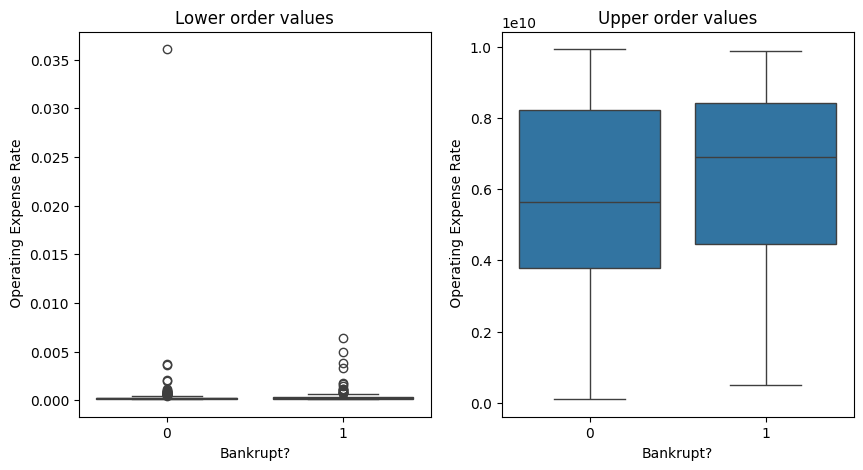

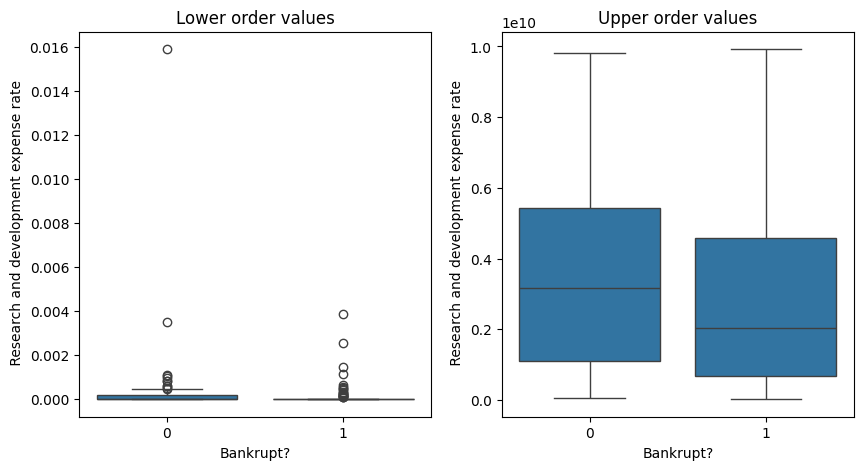

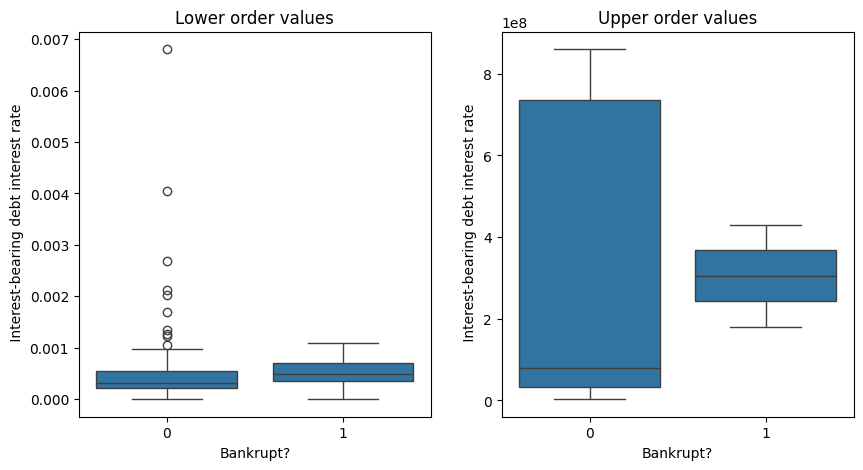

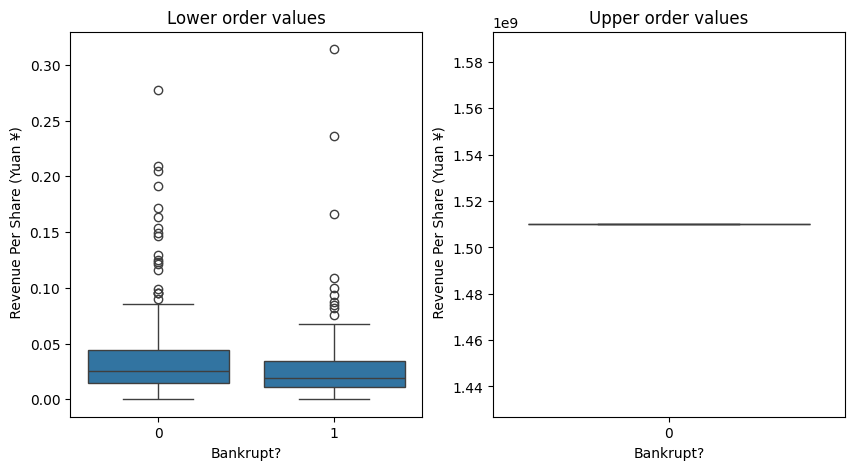

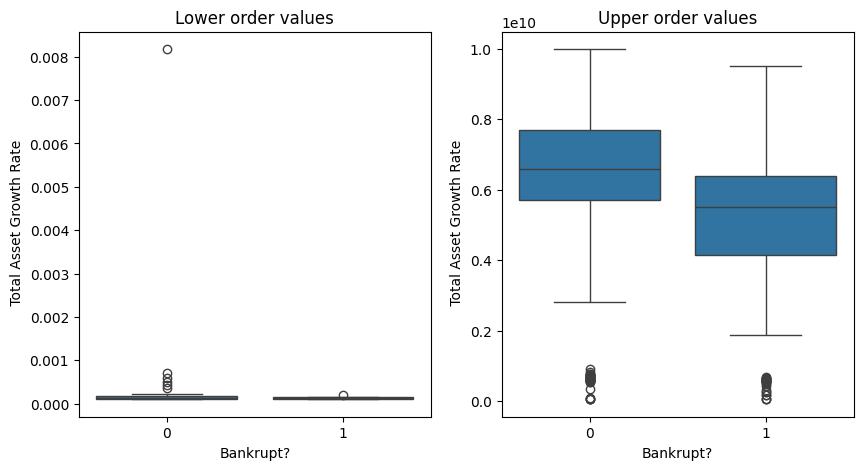

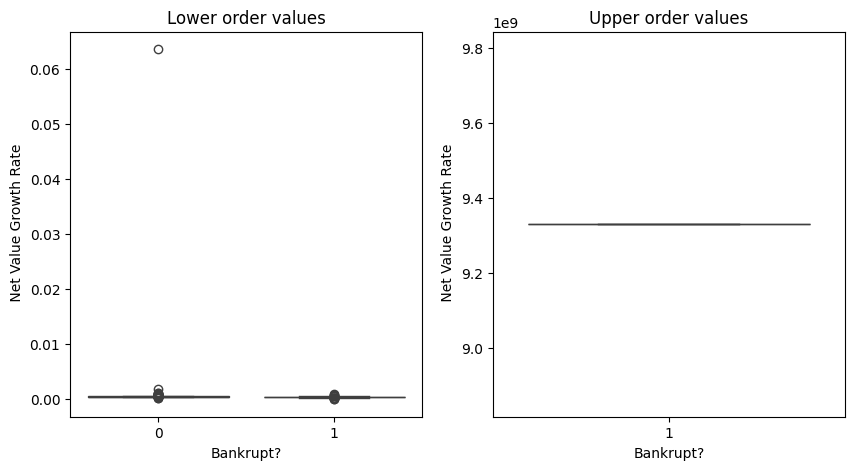

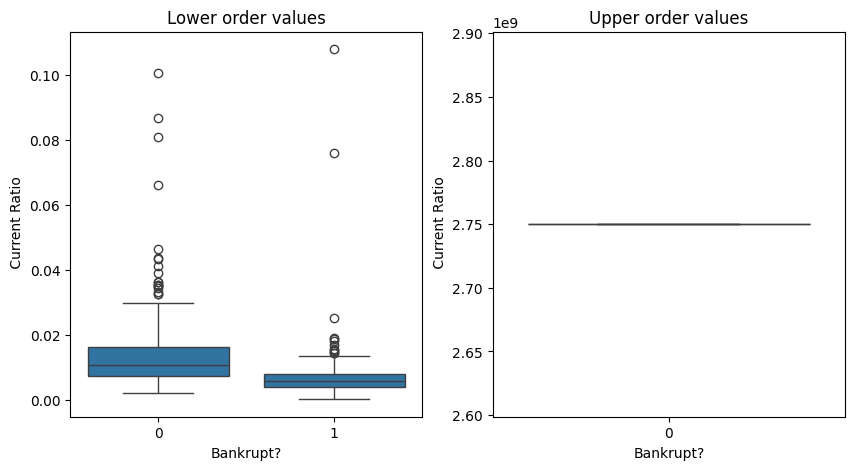

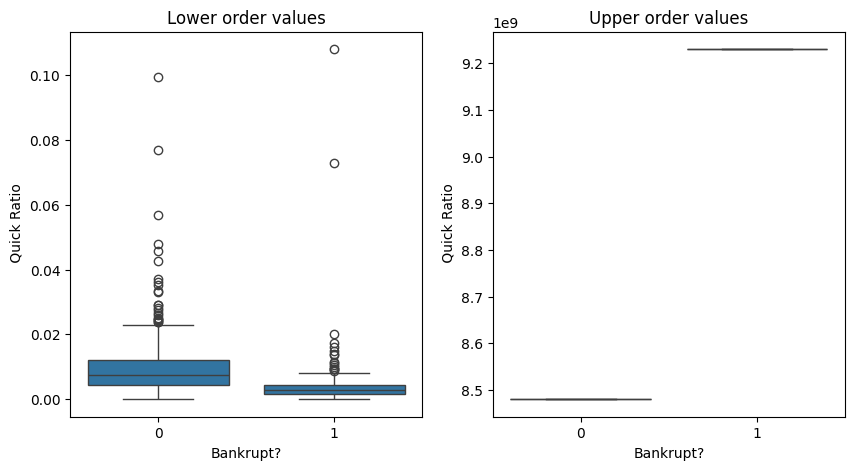

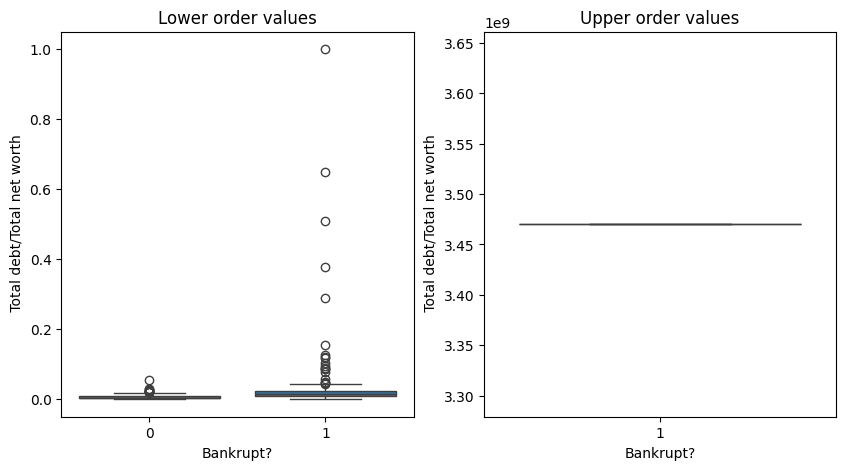

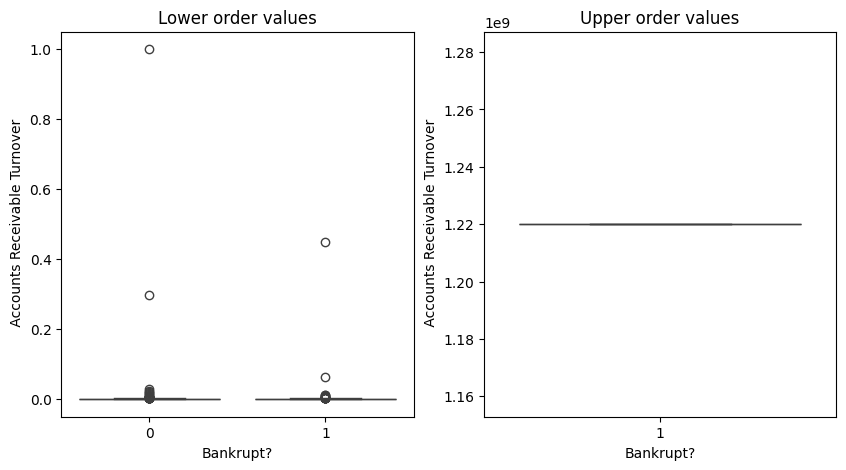

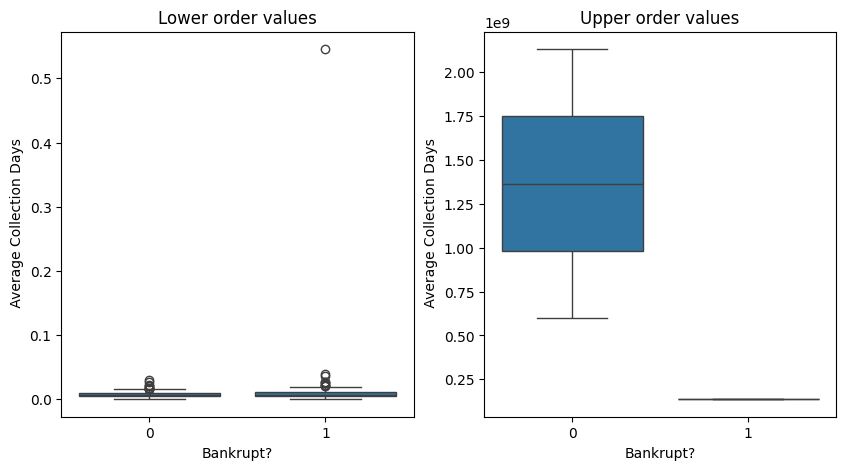

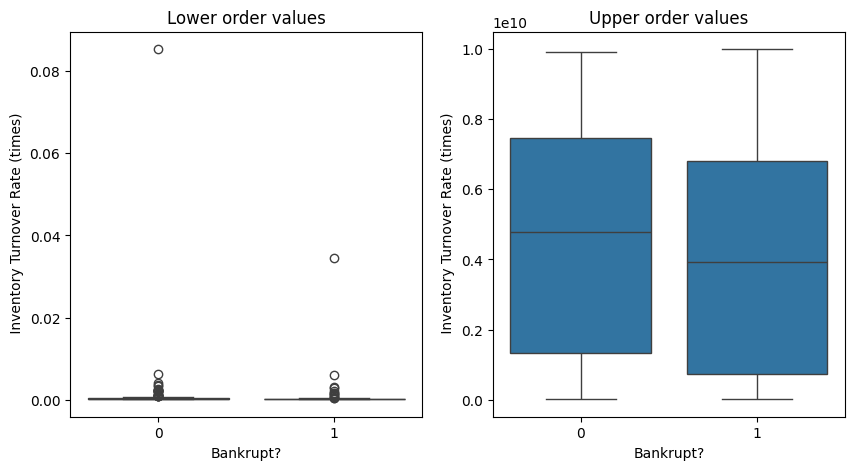

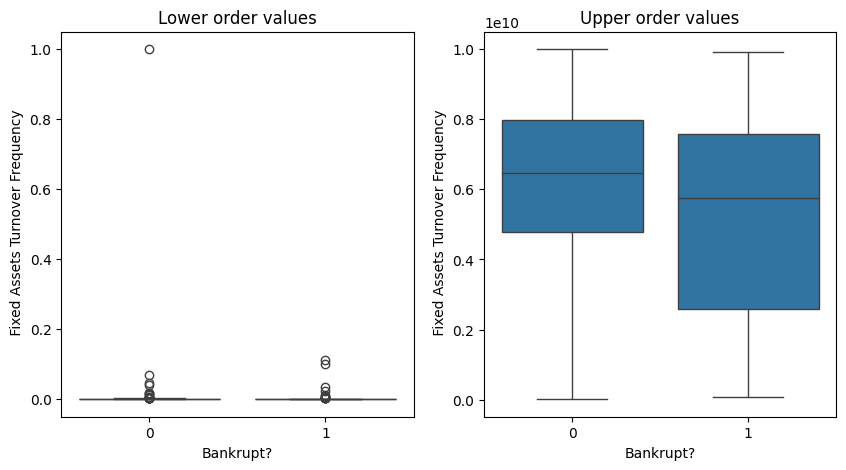

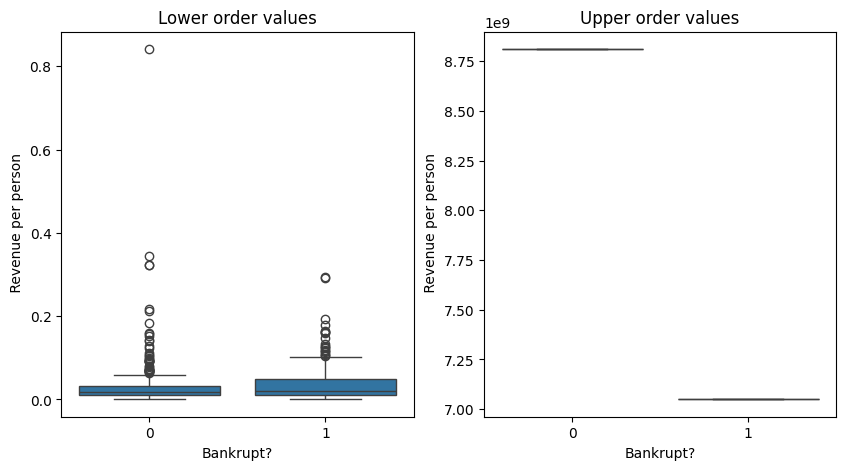

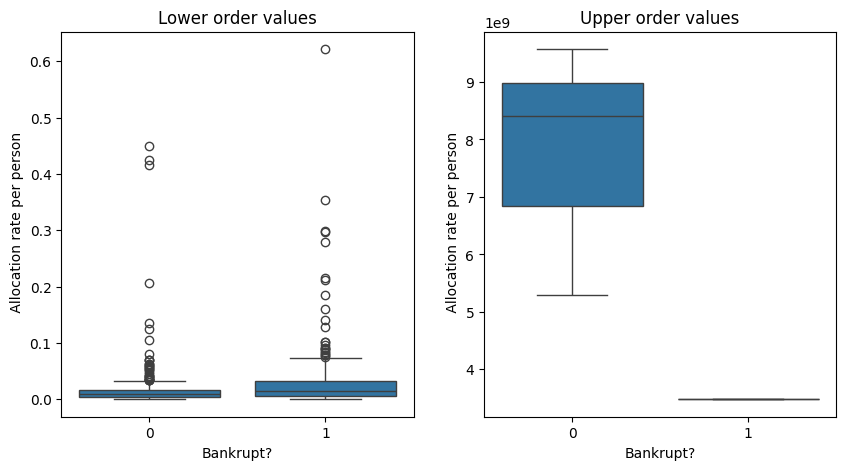

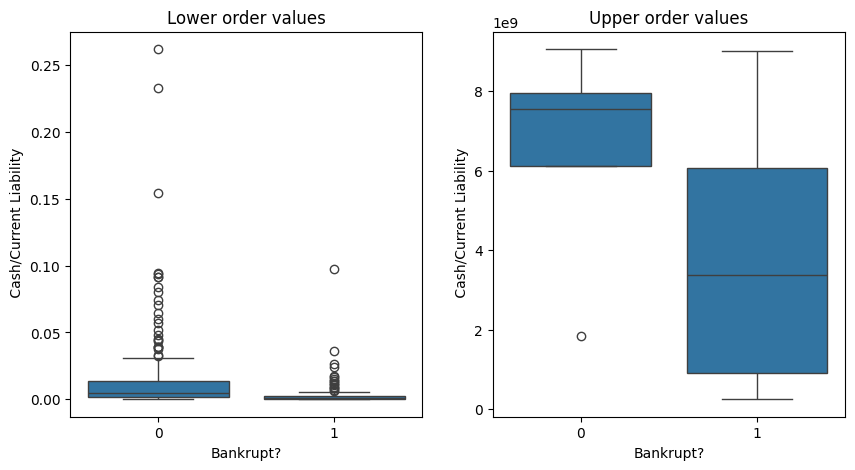

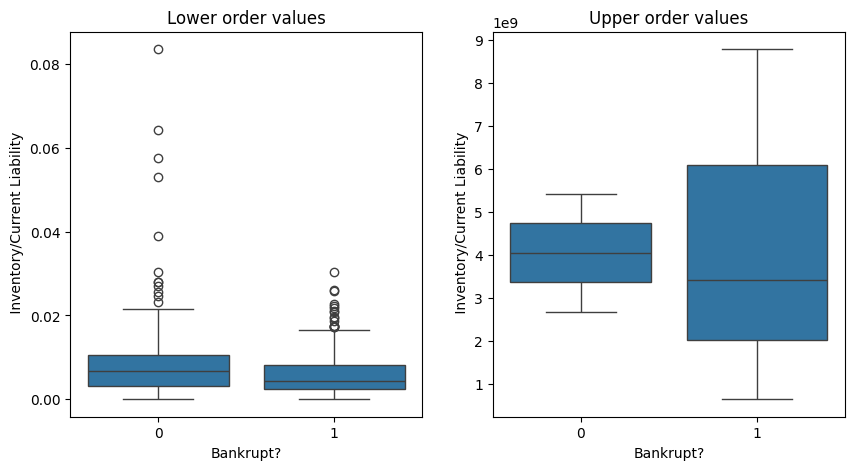

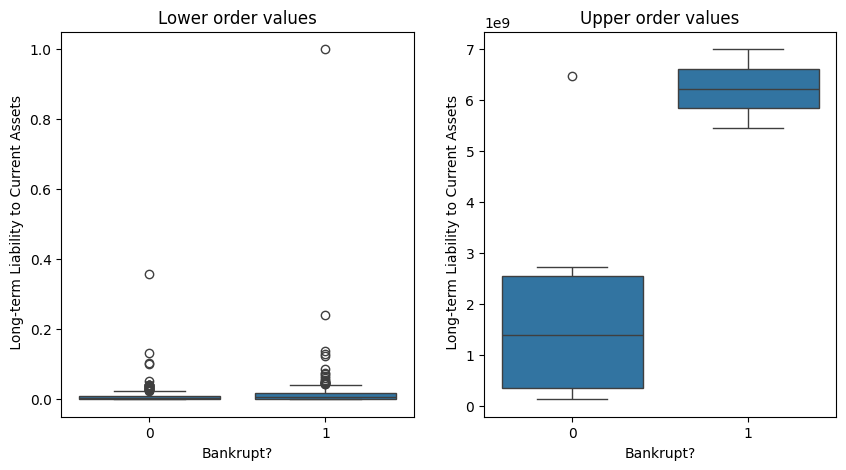

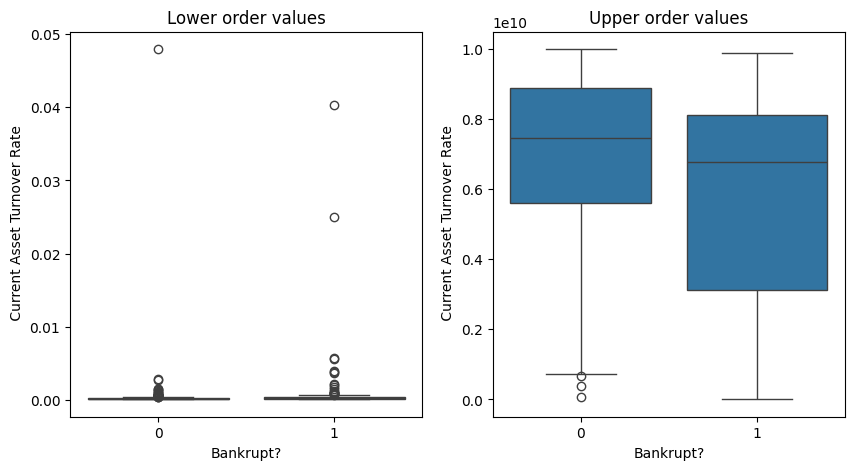

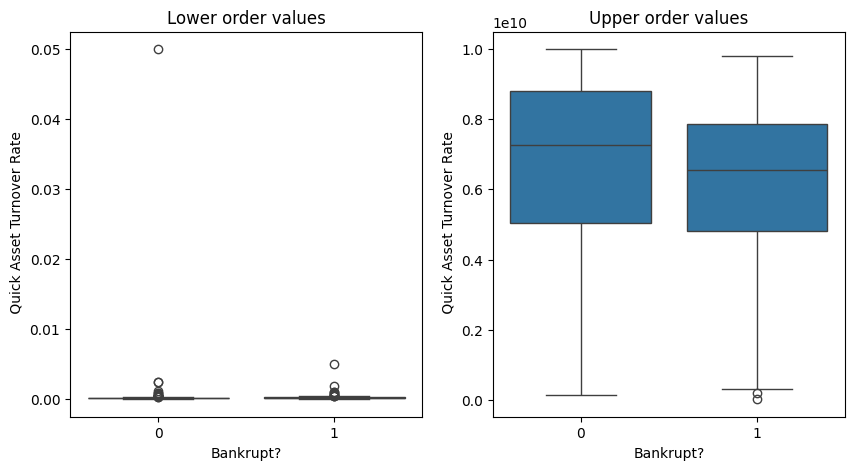

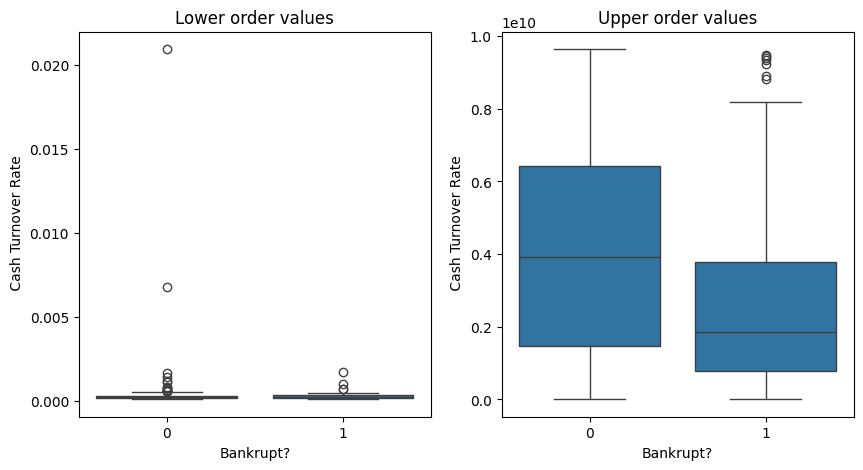

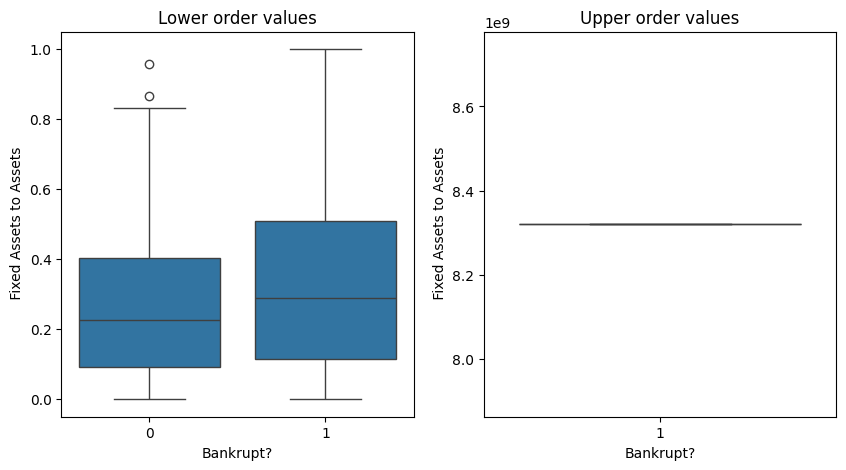

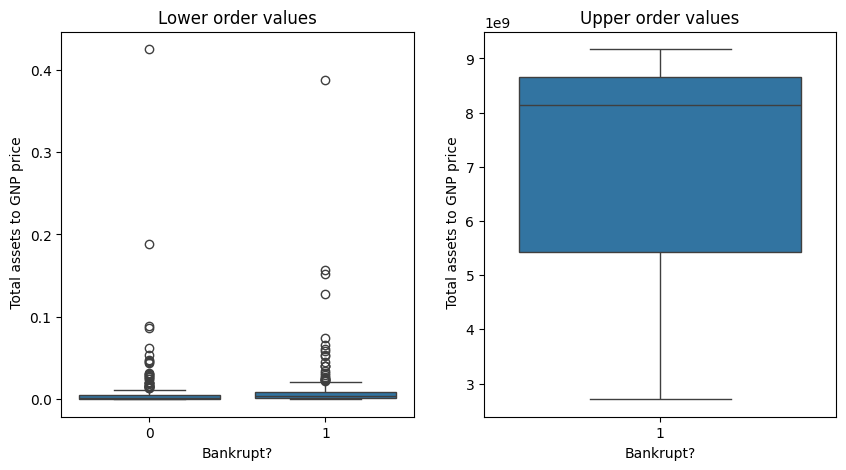

In [43]:
for column in balancedata.columns:
    if column!="Bankrupt?":
        m=balancedata[column].max()
        if m>10:
            fig,ax_=plt.subplots(nrows=1,ncols=2,figsize=(10,5))
            ax_[0]=sns.boxplot(data=balancedata[balancedata[column]<=10],
                               y=column,
                               x="Bankrupt?",ax=ax_[0])
            ax_[0].set_title("Lower order values")
            ax_[1]=sns.boxplot(data=balancedata[balancedata[column]>10],
                               y=column,
                               x="Bankrupt?",ax=ax_[1])
            ax_[1].set_title("Upper order values")
            plt.show()

In order to "squeeze" the values while keeping the details of the set of values of both ranges. In order to do so. We make the following transformation:

\begin{equation}
x'=\ln{\left(x^{\frac{1}{k}}+1 \right)}
\end{equation}

where

\begin{equation}
k=\frac{\ln{(x_{\text{max}})}}{\ln{(e-1)}}
\end{equation}

so when x=0, x'=0 and when x=x_max, x'=1. Also the greater the value, the greater the squeezing effect.

Now let's show an example. We have picked a variable with this issue. First we apply the logarithmic transformation and then the standard scaling to represent what the machine learning algorithms will get an the input.

In [44]:
x=balancedata[" Operating Expense Rate"]
f=np.log(x**(np.log(np.e-1)/np.log(x.max()))+1)
d=pd.DataFrame()
d["Original"]=x
d["LogTrans"]=f
stdscaler=StandardScaler()
stdscaler.fit(f.values.reshape(-1, 1))
d["LogTrans + StdScaling"]=stdscaler.transform(f.values.reshape(-1, 1))
d.tail(50)

,Original,LogTrans,LogTrans + StdScaling
5181,1.093921e-04,0.591644,-0.683563
2518,4.964275e-04,0.607685,-0.592995
2227,1.821275e-04,0.597016,-0.653236
1402,1.598096e-04,0.595635,-0.661032
1430,3.080000e+09,0.982687,1.524262
5606,2.468839e-04,0.600238,-0.635042
3054,1.039572e-04,0.591109,-0.686583
565,1.337914e-04,0.593761,-0.671609
6168,2.210970e-04,0.599068,-0.641648
3463,2.405239e-04,0.599961,-0.636606


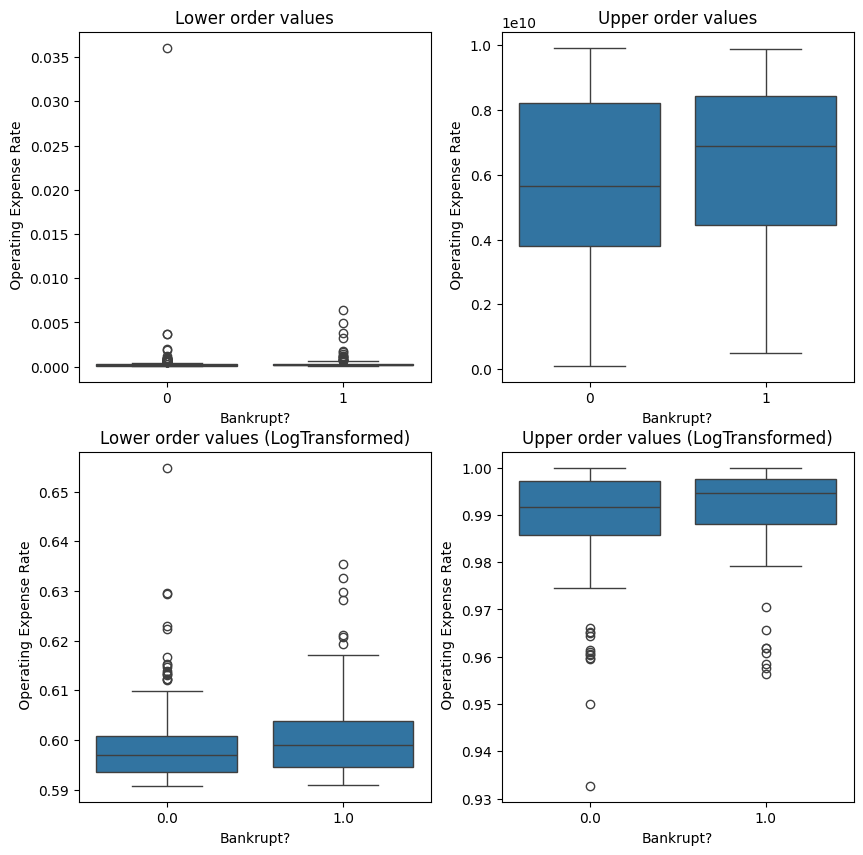

In [45]:
fig,ax_=plt.subplots(nrows=2,ncols=2,figsize=(10,10))

ax_[0,0]=sns.boxplot(data=balancedata[balancedata[" Operating Expense Rate"]<=10],
                     y=" Operating Expense Rate",
                     x="Bankrupt?",
                     ax=ax_[0,0])
ax_[0,0].set_title("Lower order values")
ax_[0,1]=sns.boxplot(data=balancedata[balancedata[" Operating Expense Rate"]>10],
                     y=" Operating Expense Rate",
                     x="Bankrupt?",
                     ax=ax_[0,1])
ax_[0,1].set_title("Upper order values")

m=balancedata[" Operating Expense Rate"].max()

ax_[1,0]=sns.boxplot(data=balancedata[balancedata[" Operating Expense Rate"]<=10],
                     y=balancedata[" Operating Expense Rate"].apply(lambda x: np.log(x**(np.log(np.e-1)/np.log(m))+1)),
                     x="Bankrupt?",
                     ax=ax_[1,0])
ax_[1,0].set_title("Lower order values (LogTransformed)")
ax_[1,1]=sns.boxplot(data=balancedata[balancedata[" Operating Expense Rate"]>10],
                     y=balancedata[" Operating Expense Rate"].apply(lambda x: np.log(x**(np.log(np.e-1)/np.log(m))+1)),
                     x="Bankrupt?",
                     ax=ax_[1,1])
ax_[1,1].set_title("Upper order values (LogTransformed)")

plt.show()

It represents quite well what we wanted to achieve. The price to pay is distorting the general value distribution, so the algorithms that suppose linear features-output dependencies will be affected, but the one that depend mainly on the relative differences between positive and negative distribution will perform even better, since they will be more sensitive to the lower order values distribution details.

Now the value of k for each affected variable will be shown, along with the maximum value, the mean and the median of each one.

In [46]:
dinfo={}
for col in balancedata.columns:
    info={}
    info["median"]=balancedata[col].median()
    info["mean"]=balancedata[col].mean()
    info["max"]=balancedata[col].max()
    info["k"]=np.log(balancedata[col].max())/np.log(np.e-1)
    dinfo[col]=info
datainfo=pd.DataFrame.from_dict(dinfo, orient="index")
datainfo[datainfo["max"]>1]

,median,mean,max,k
Operating Expense Rate,2.700690e-04,1.708378e+09,9.930000e+09,42.523128
Research and development expense rate,3.910000e+08,1.925270e+09,9.920000e+09,42.521267
Interest-bearing debt interest rate,3.835384e-04,5.618182e+06,8.600000e+08,38.003877
Revenue Per Share (Yuan ¥),2.320886e-02,2.745455e+06,1.510000e+09,39.043793
Total Asset Growth Rate,5.930000e+09,5.139233e+09,9.980000e+09,42.532407
Net Value Growth Rate,4.481308e-04,1.696364e+07,9.330000e+09,42.407993
Current Ratio,8.301378e-03,5.000000e+06,2.750000e+09,40.151245
Quick Ratio,4.914927e-03,3.220000e+07,9.230000e+09,42.388087
Total debt/Total net worth,8.679178e-03,6.309091e+06,3.470000e+09,40.580846
Accounts Receivable Turnover,9.373764e-04,2.218182e+06,1.220000e+09,38.649836


## 3. Data analysis

Now the distribution of the regular variables and the tranformed ones will be shown.

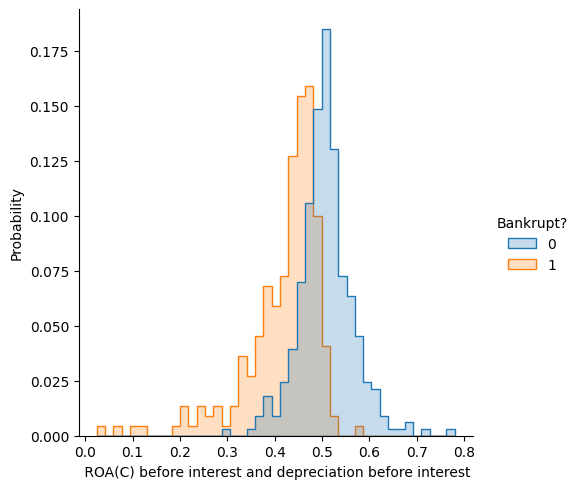

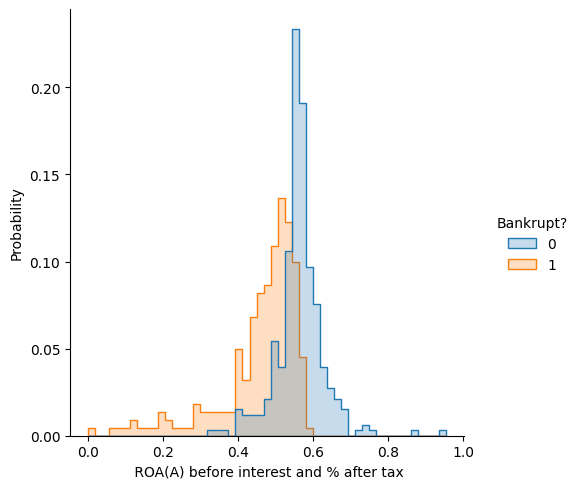

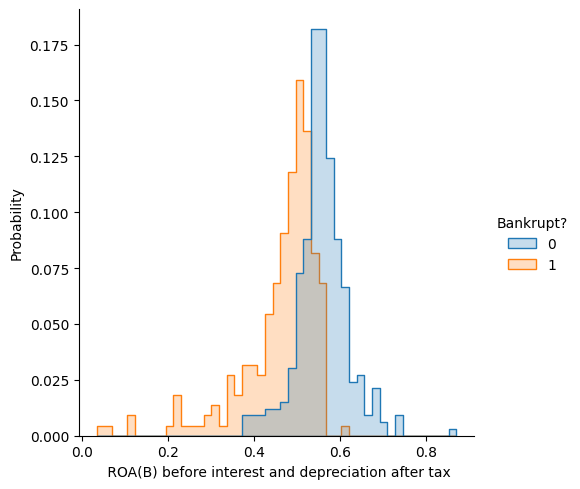

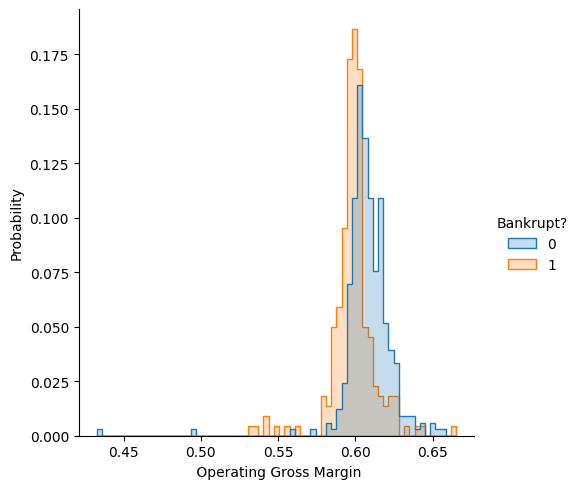

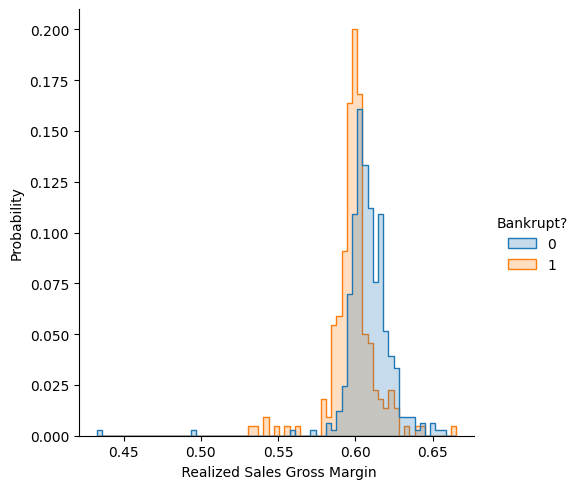

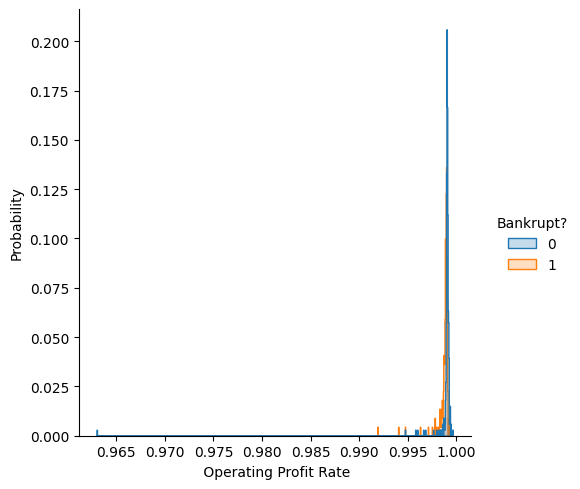

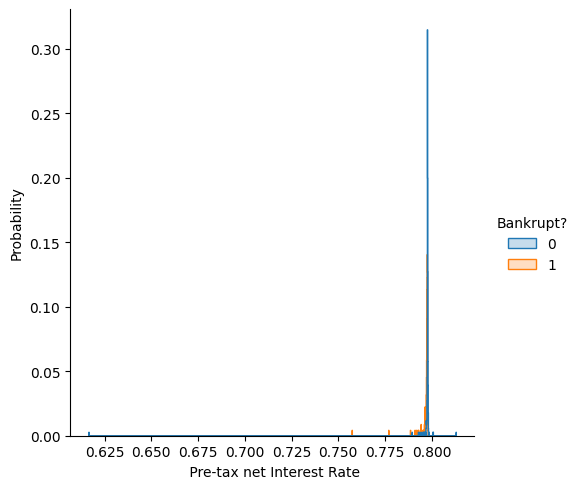

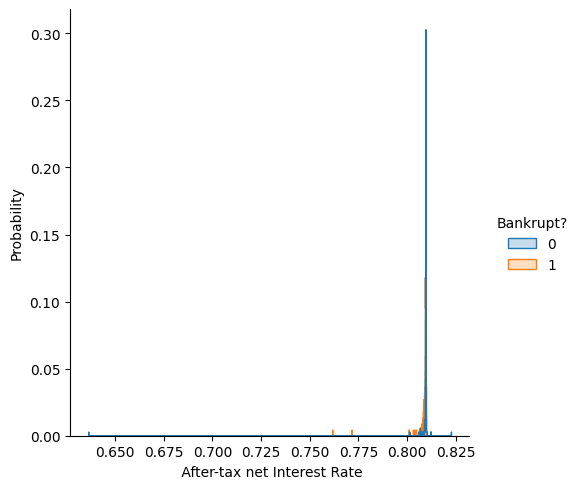

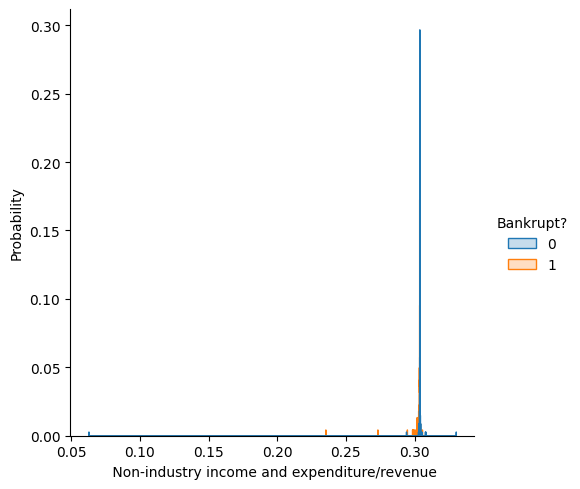

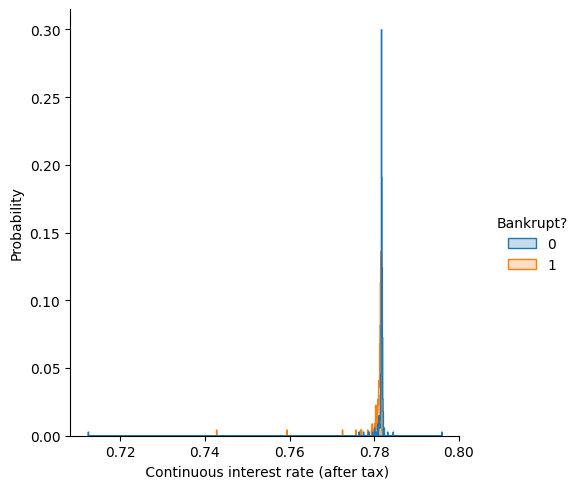

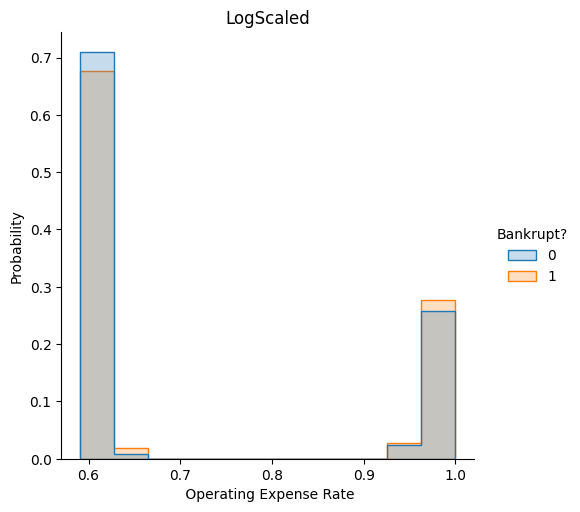

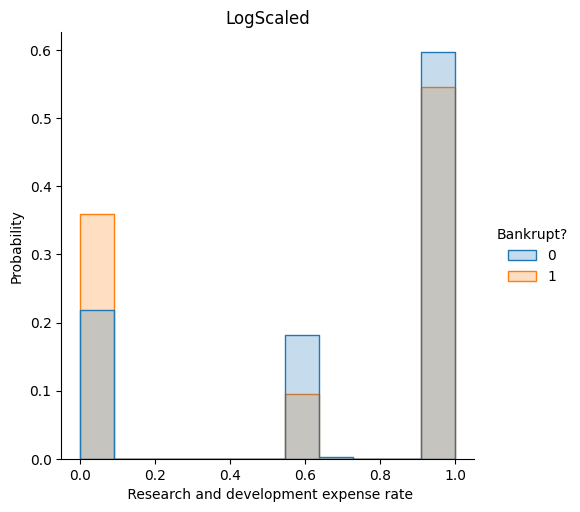

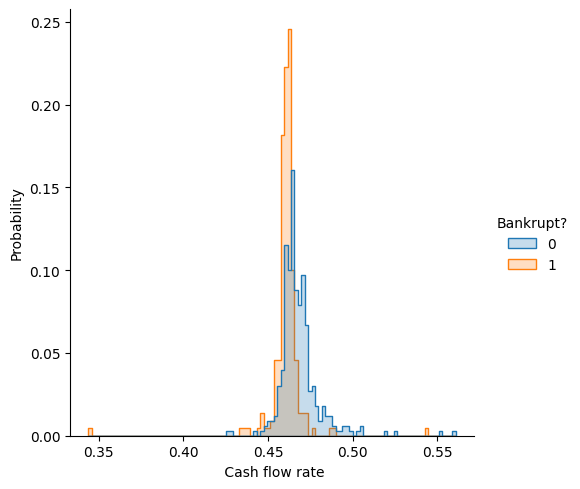

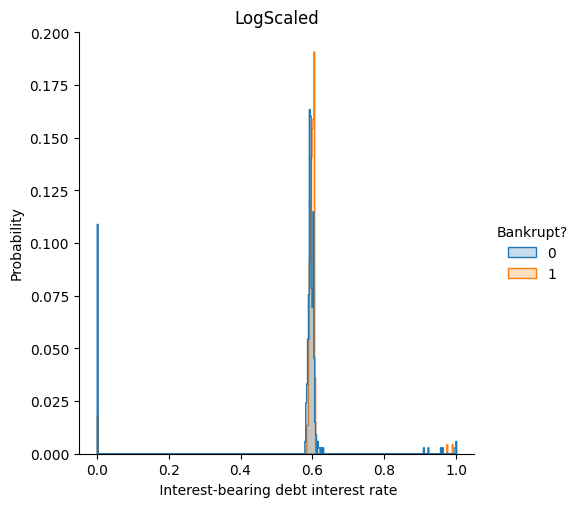

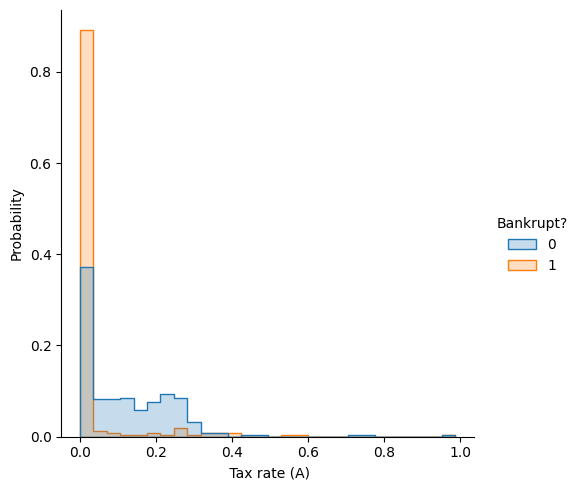

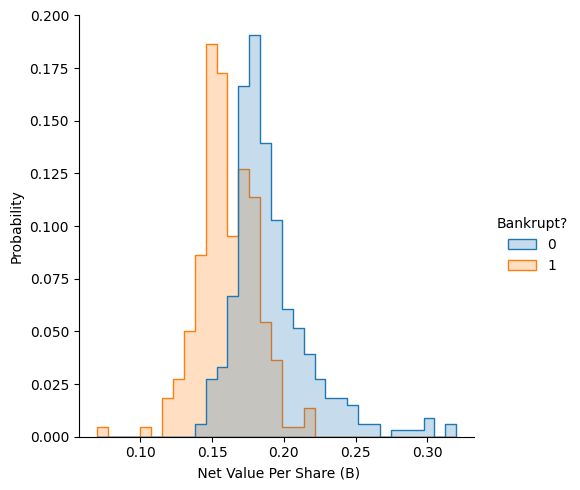

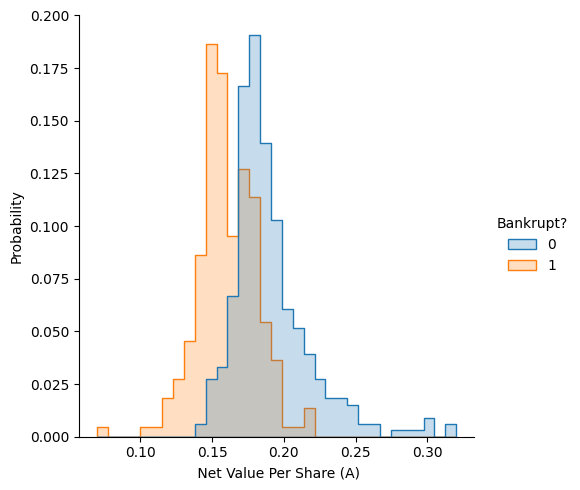

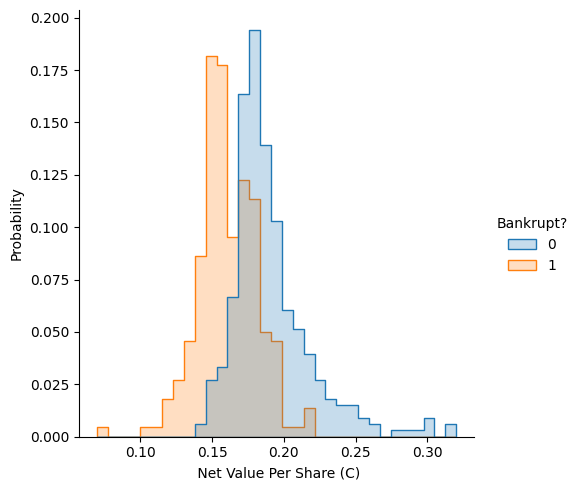

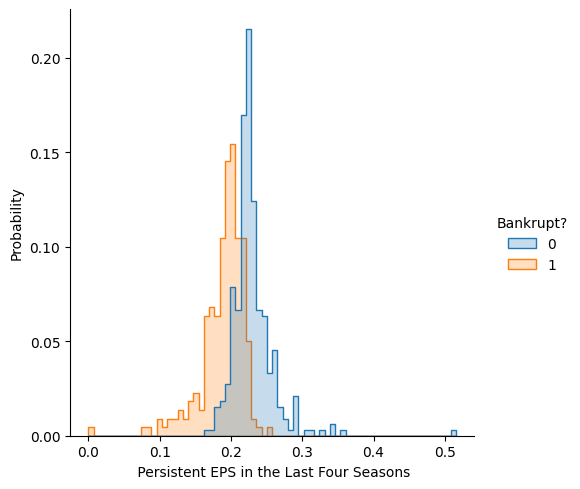

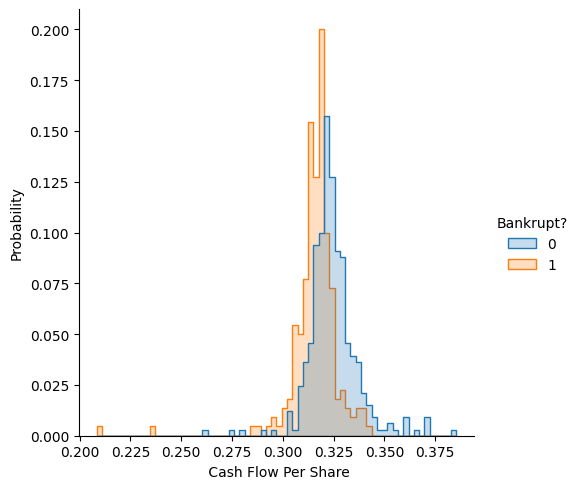

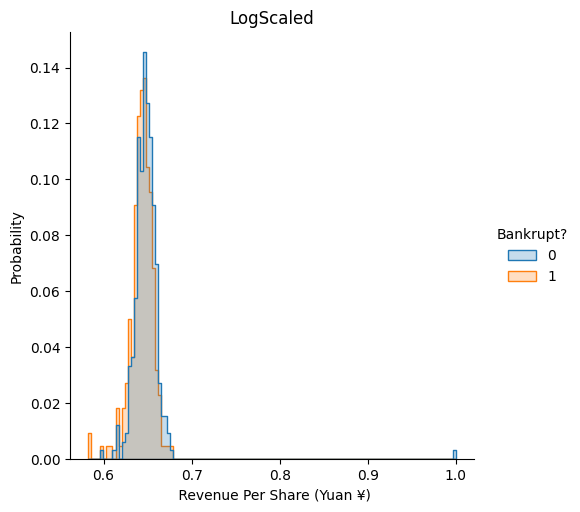

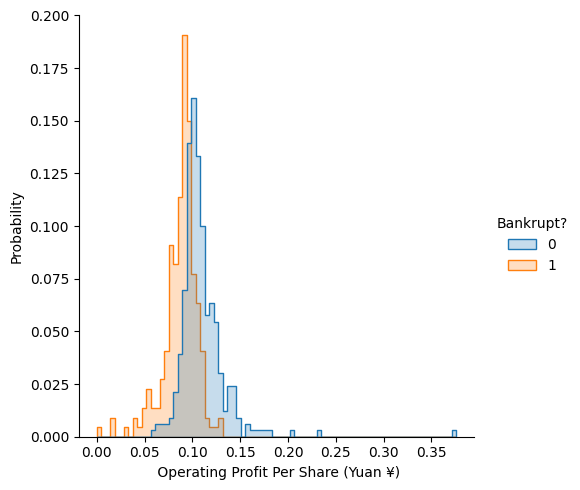

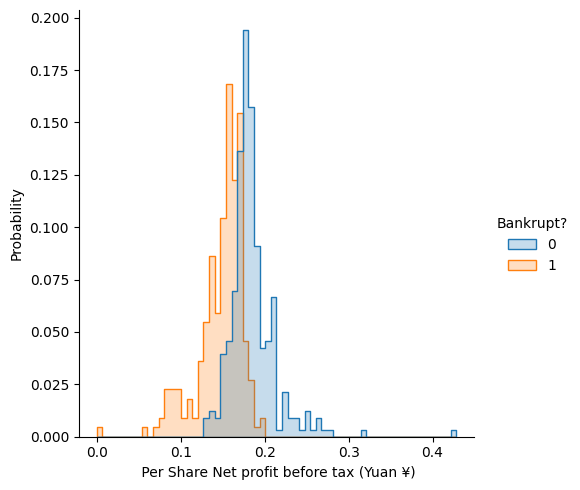

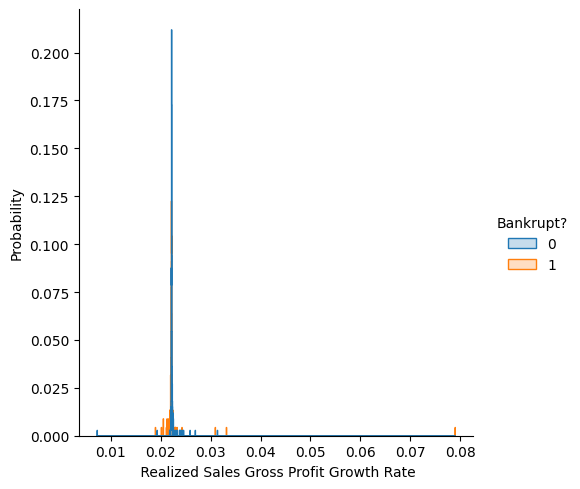

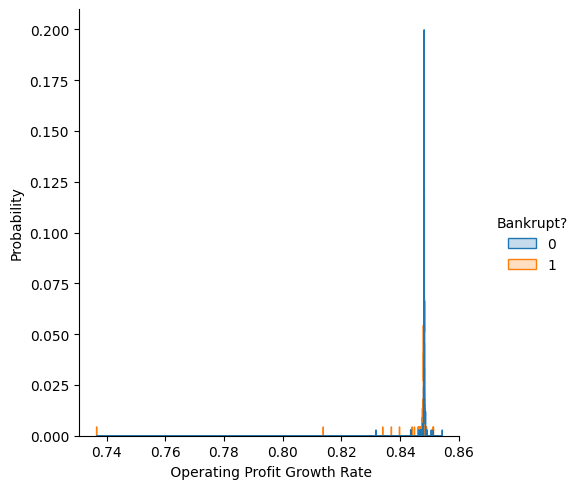

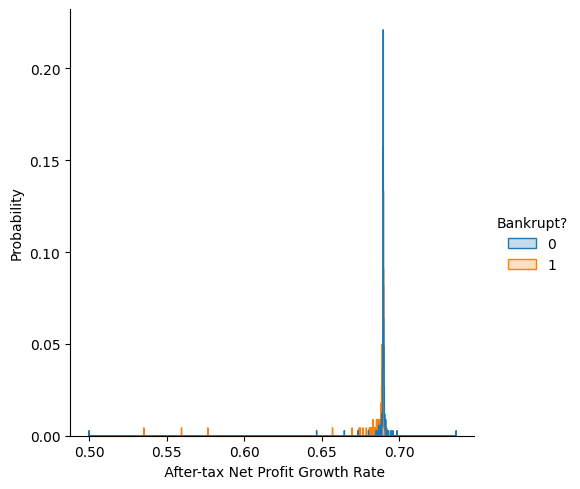

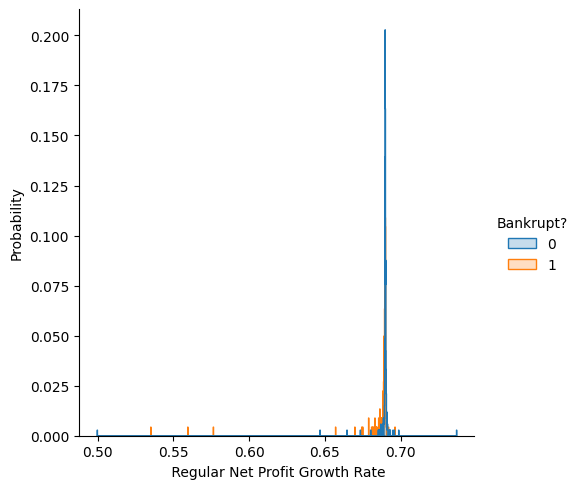

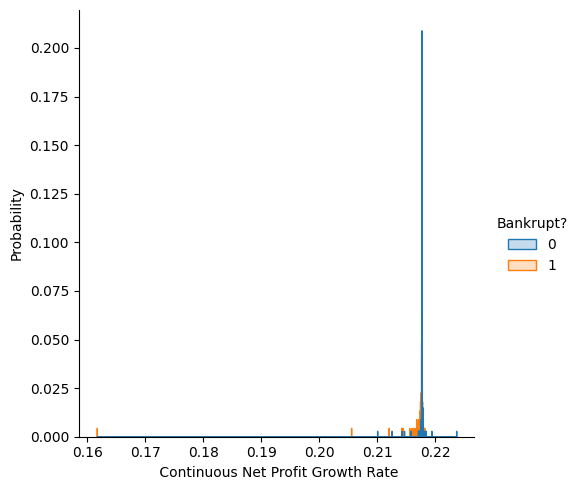

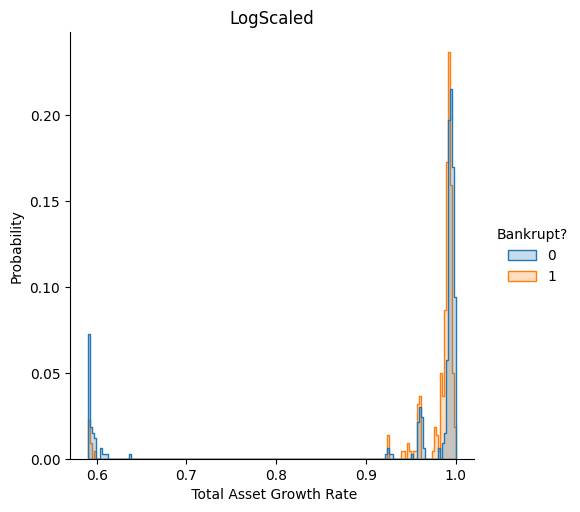

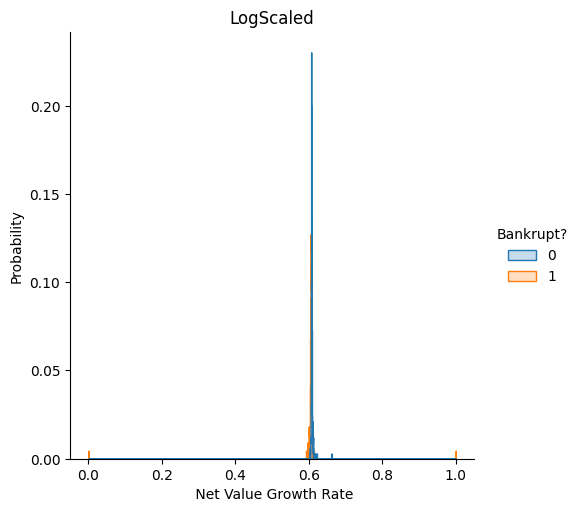

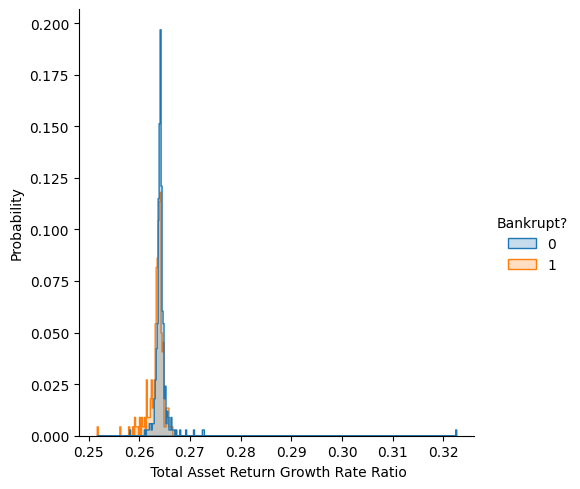

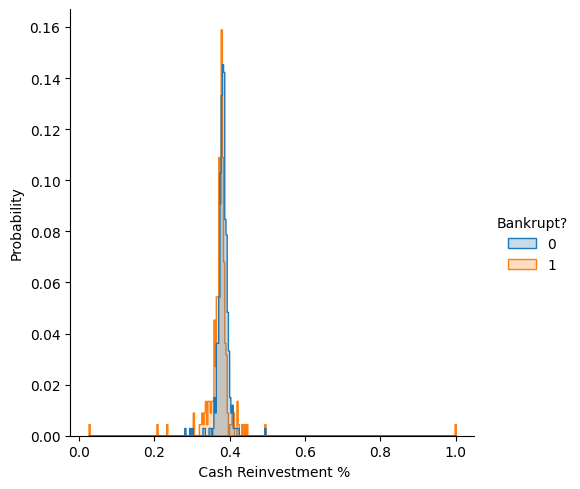

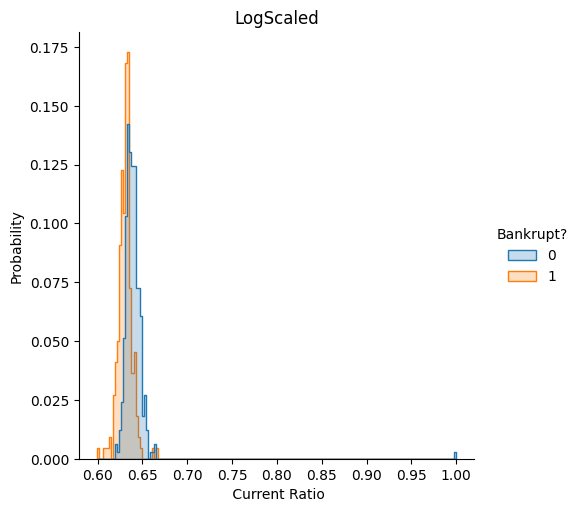

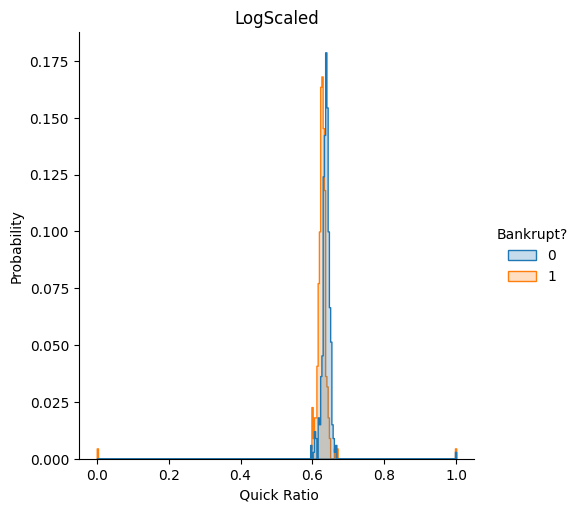

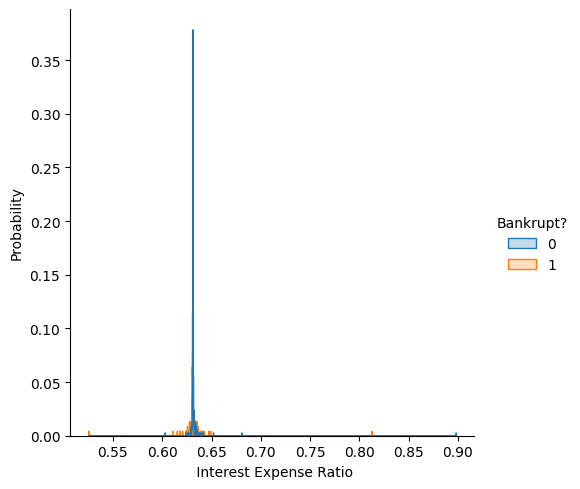

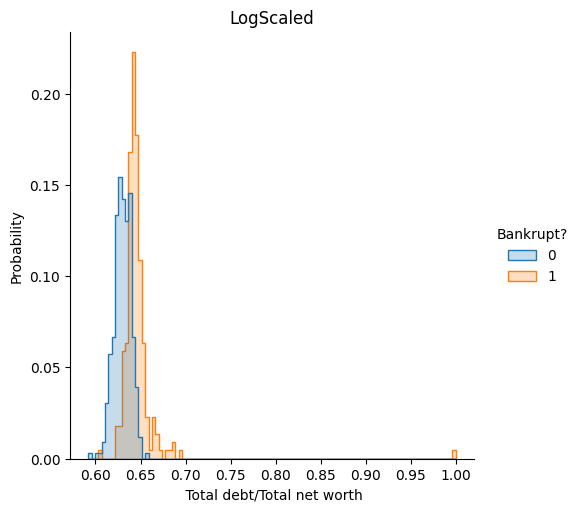

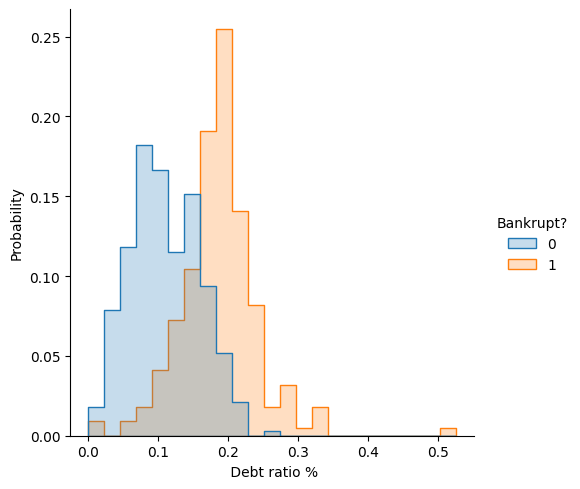

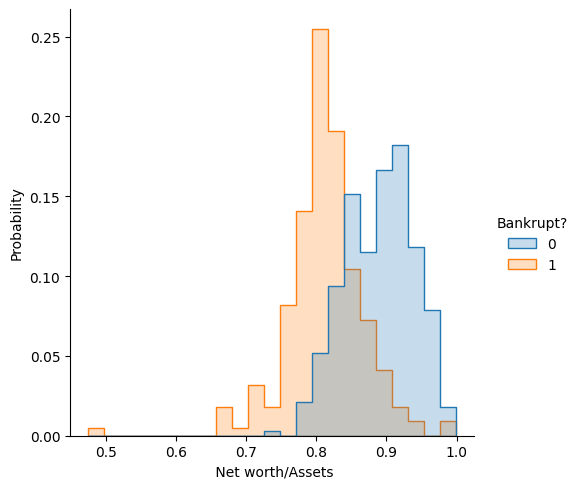

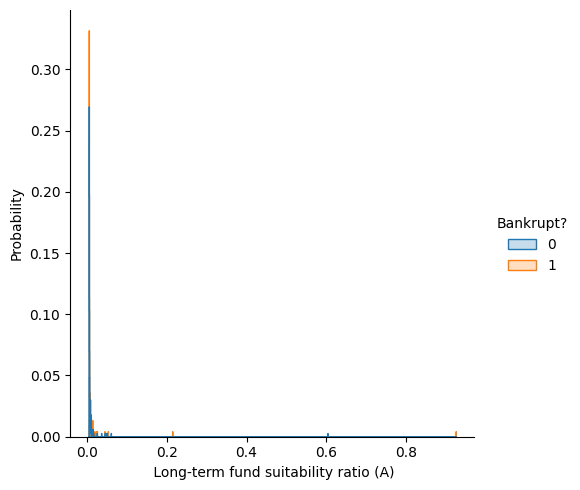

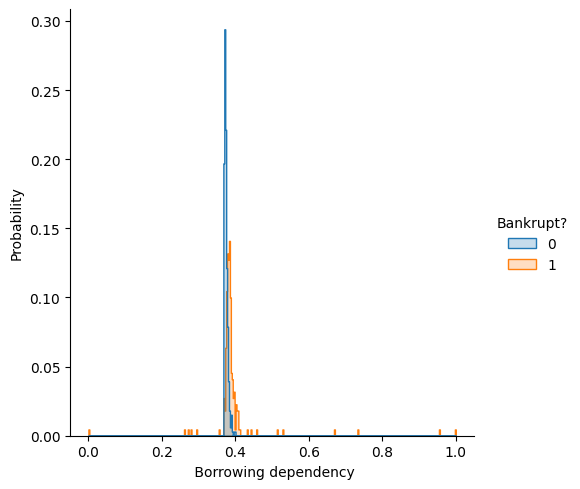

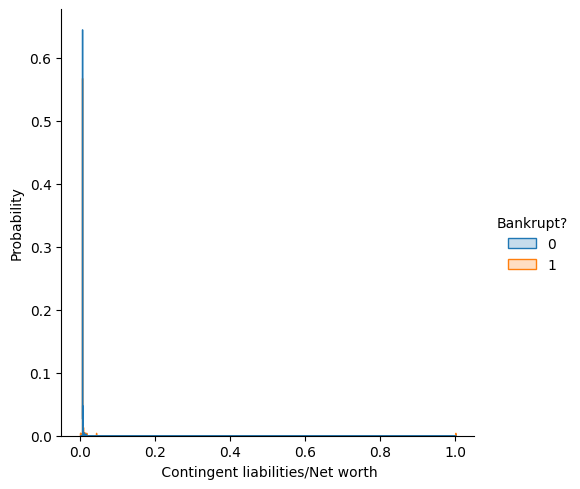

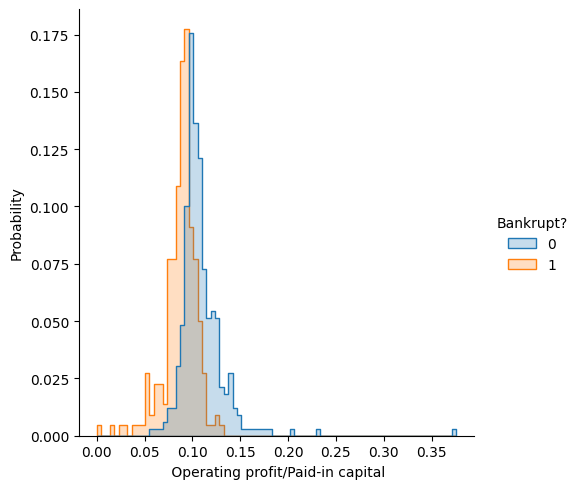

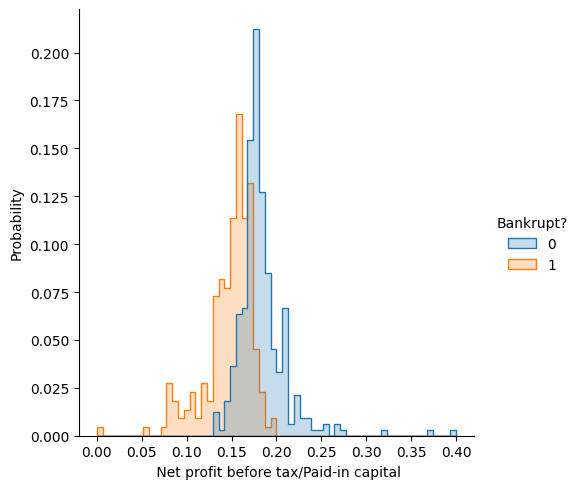

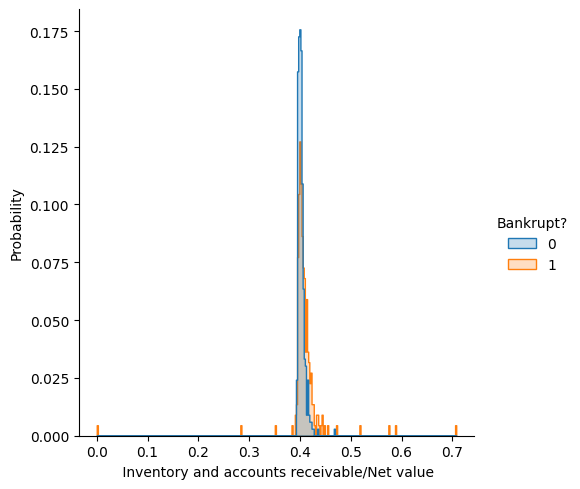

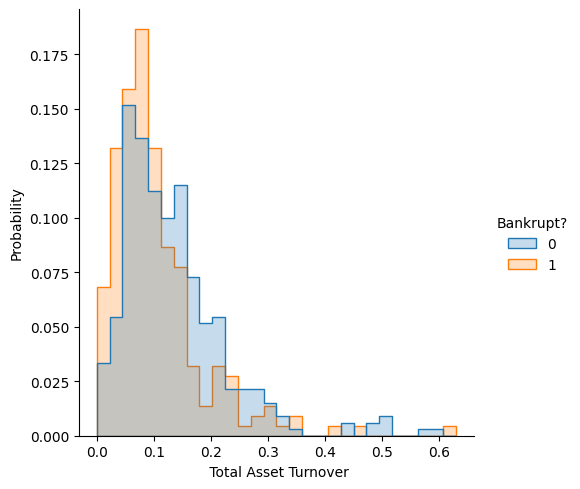

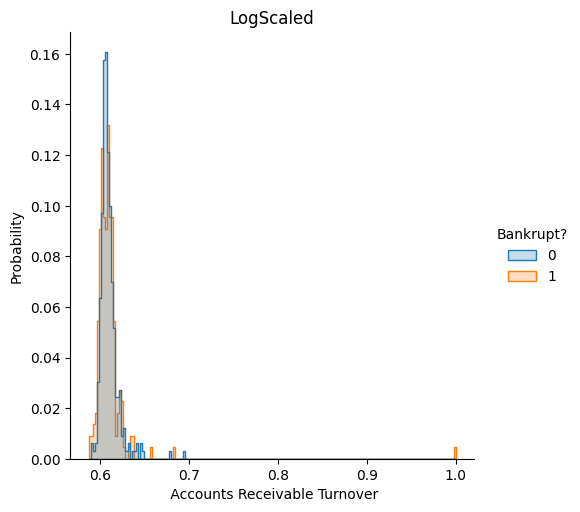

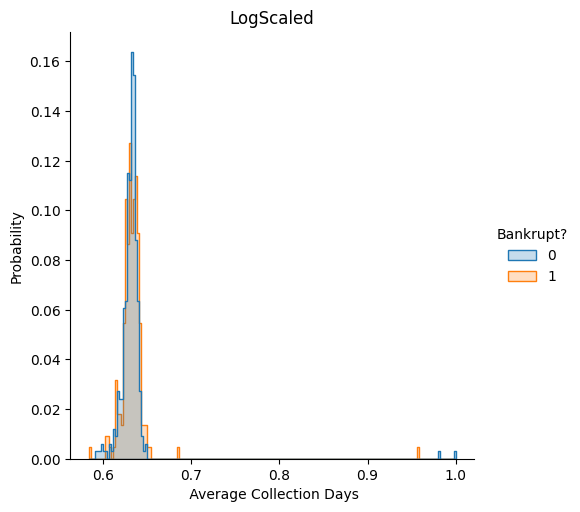

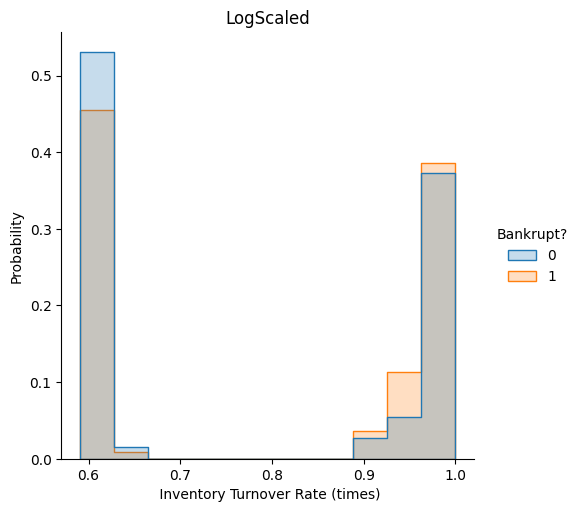

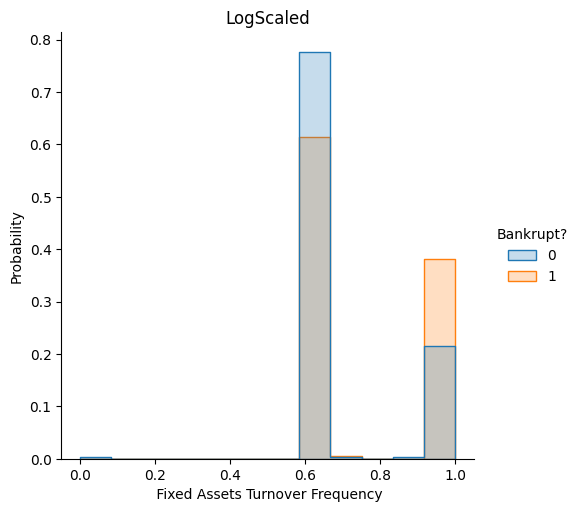

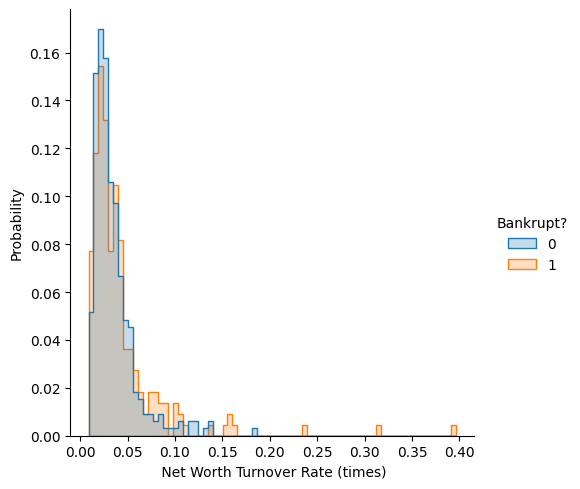

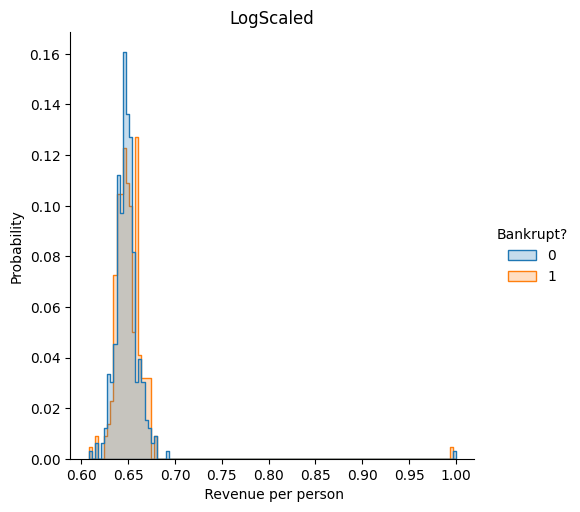

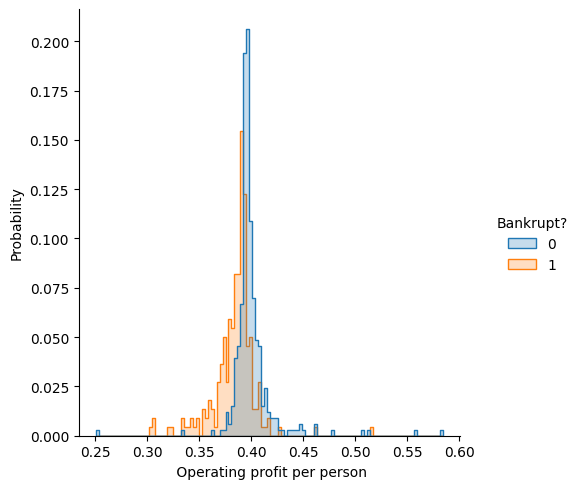

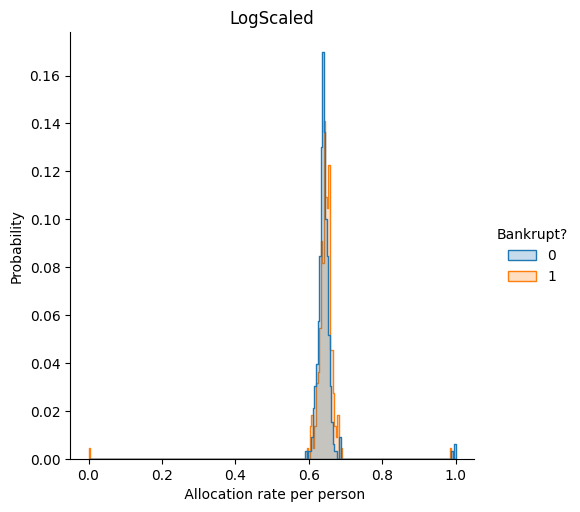

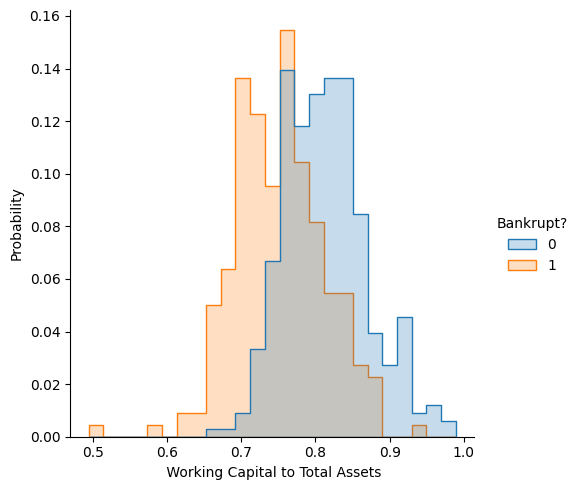

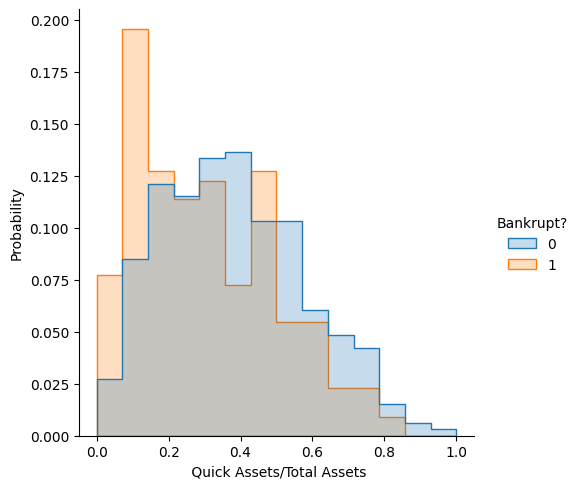

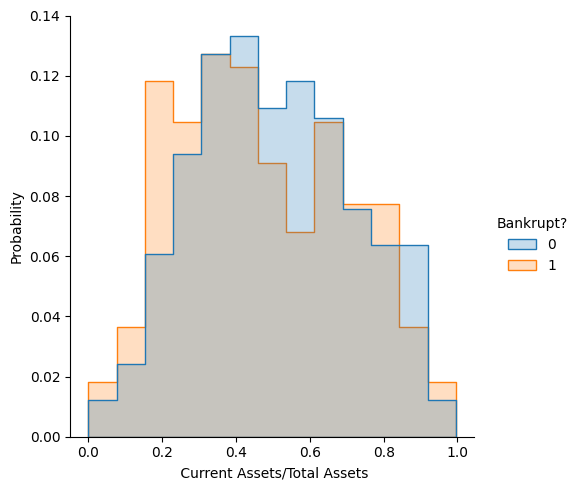

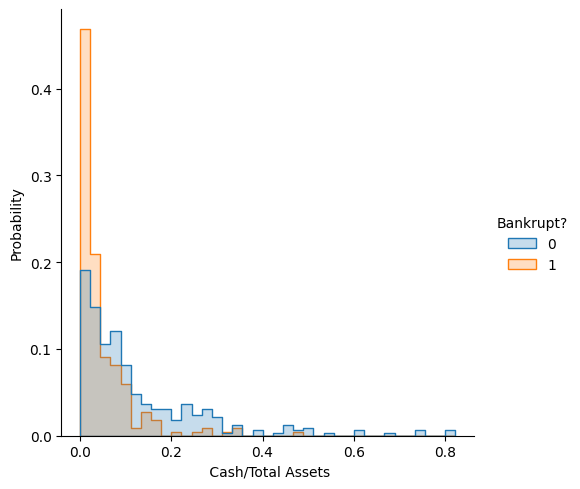

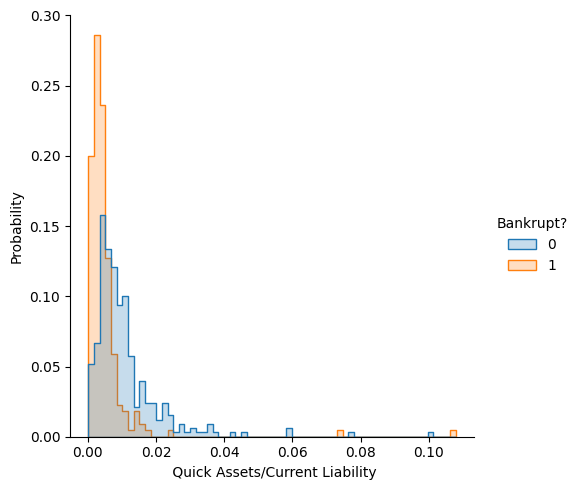

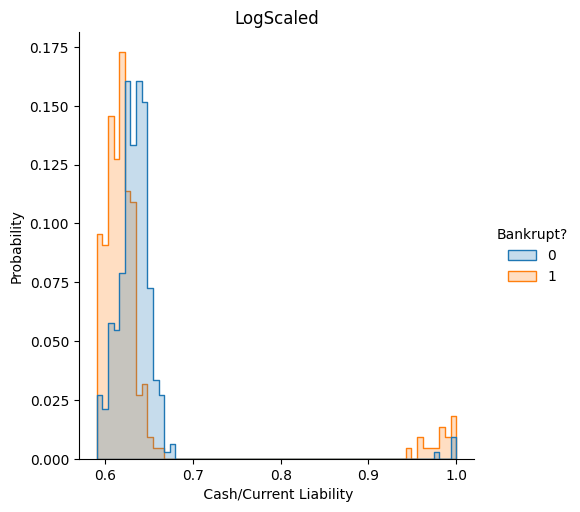

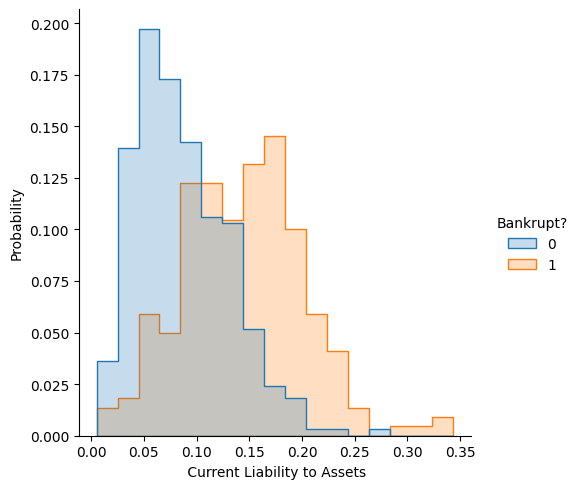

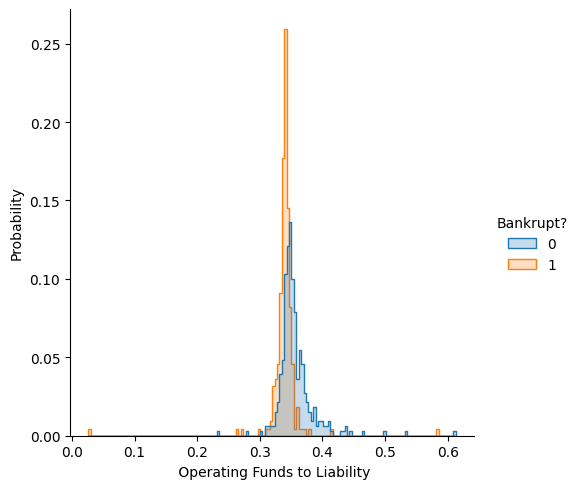

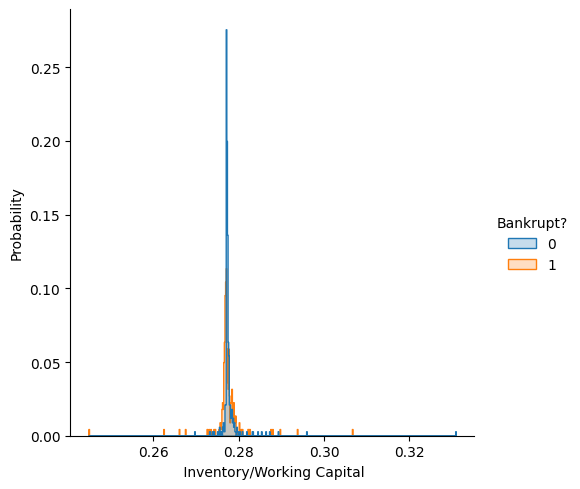

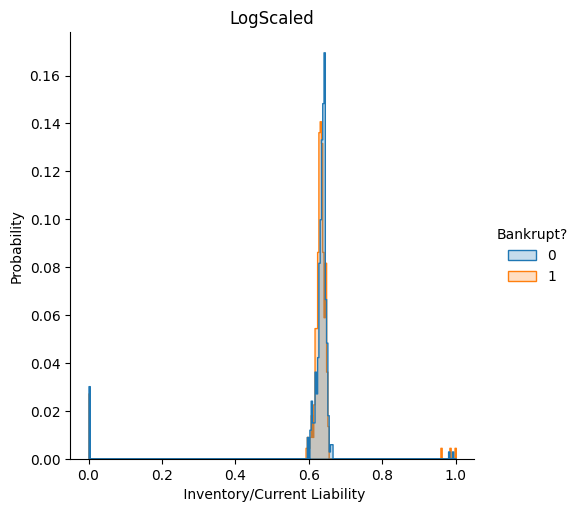

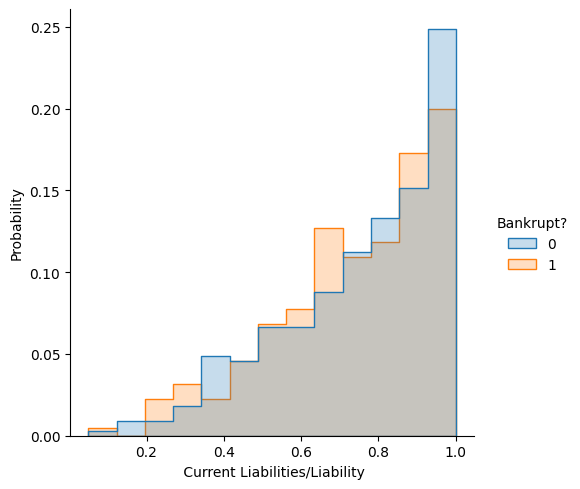

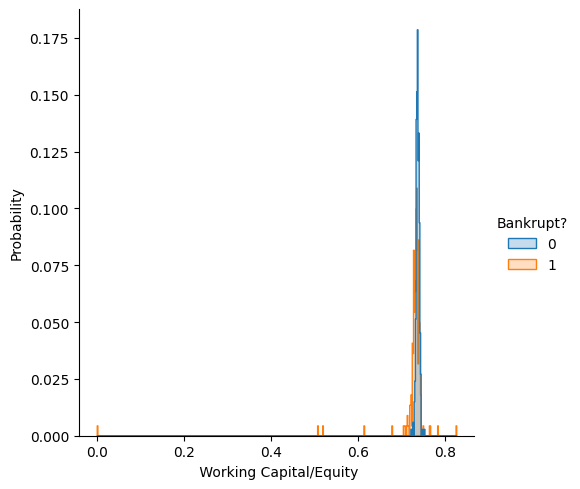

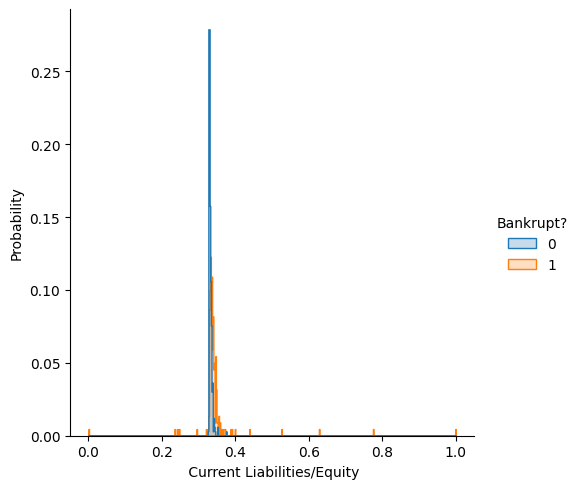

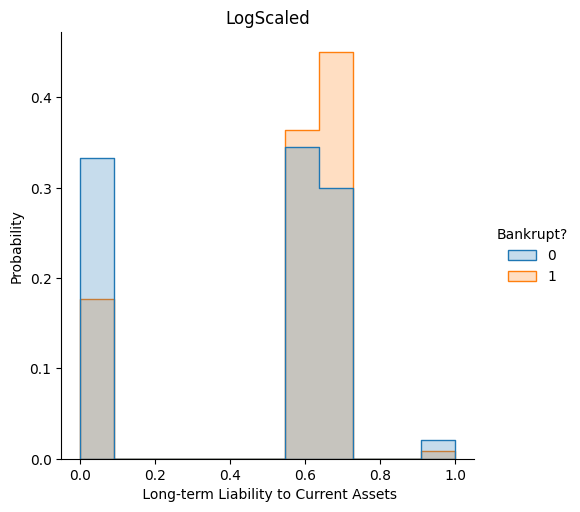

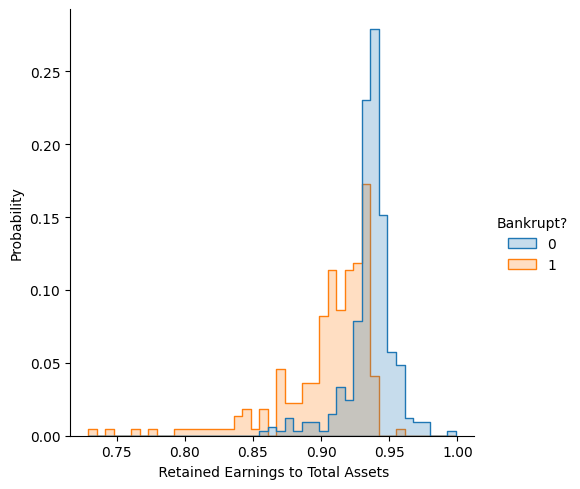

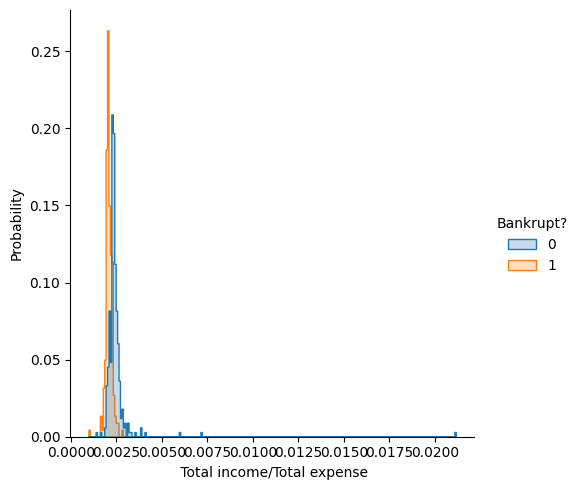

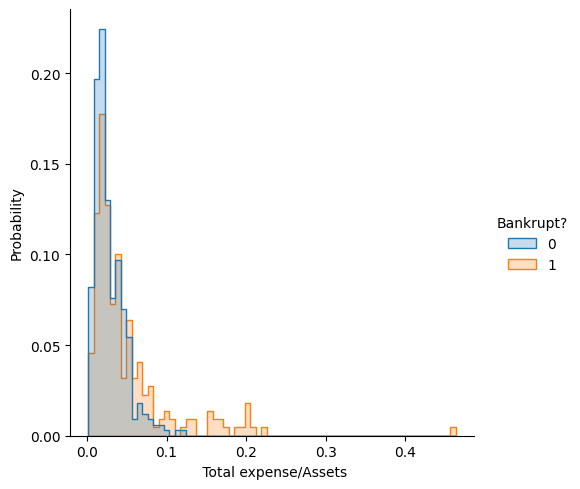

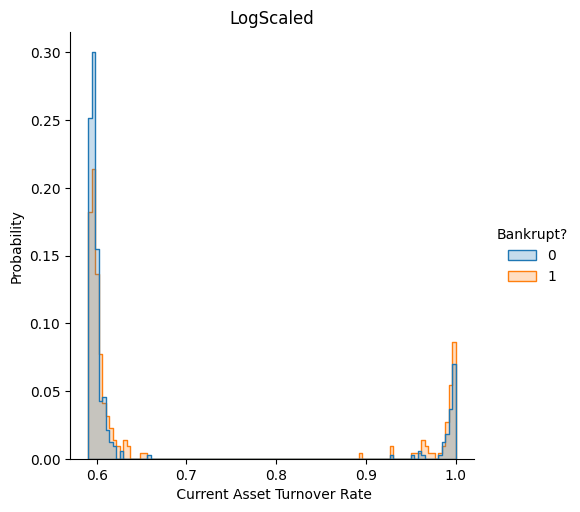

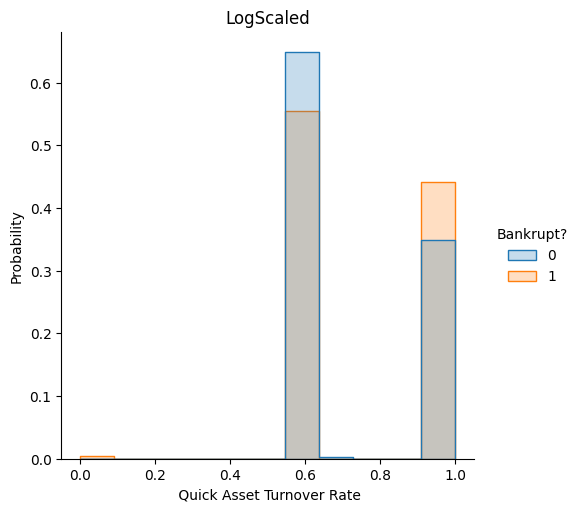

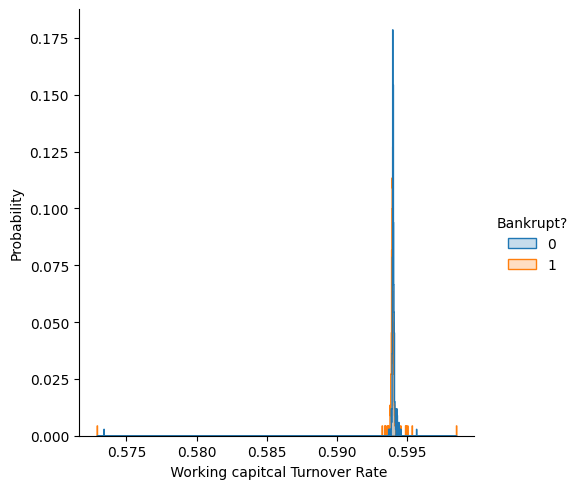

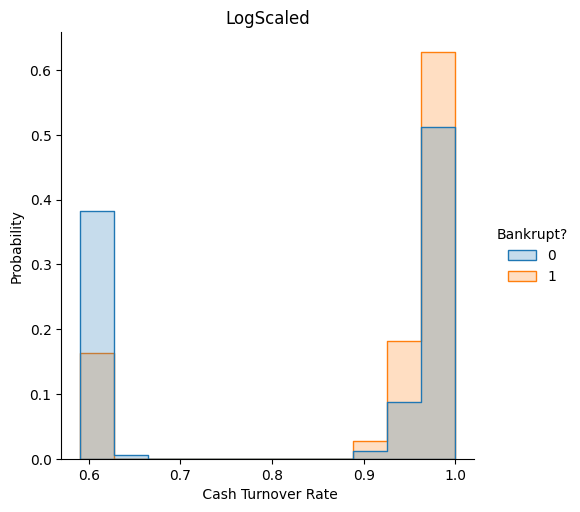

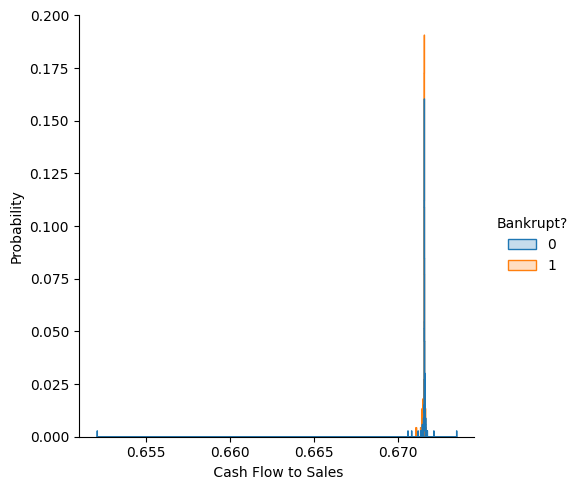

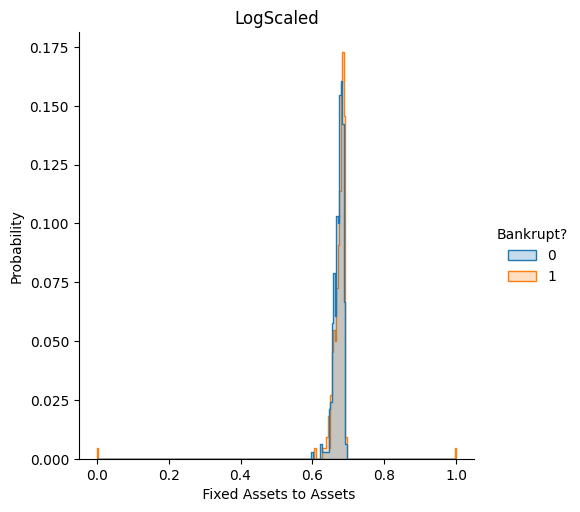

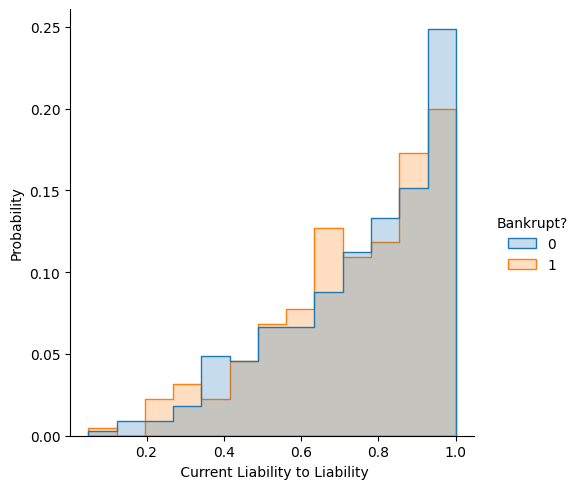

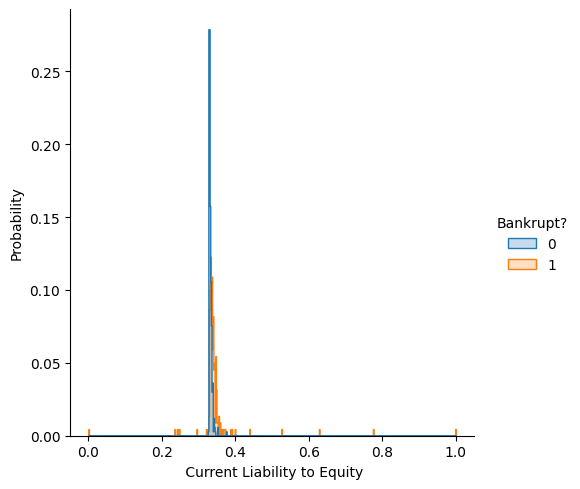

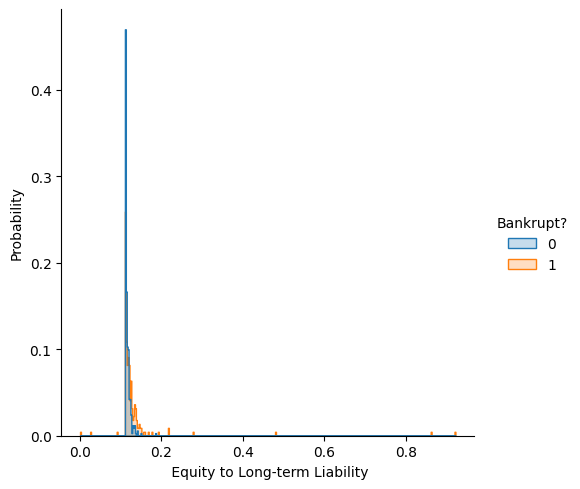

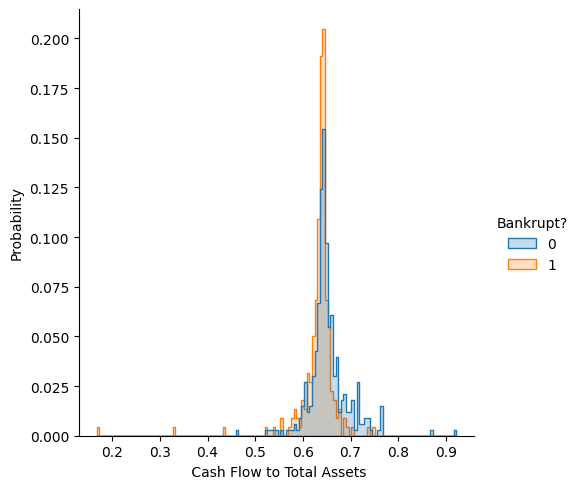

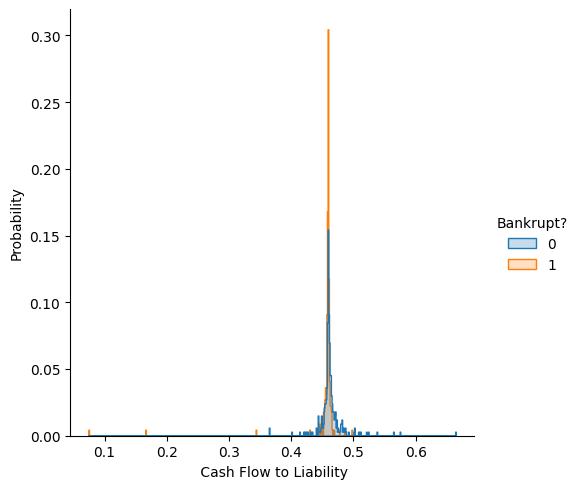

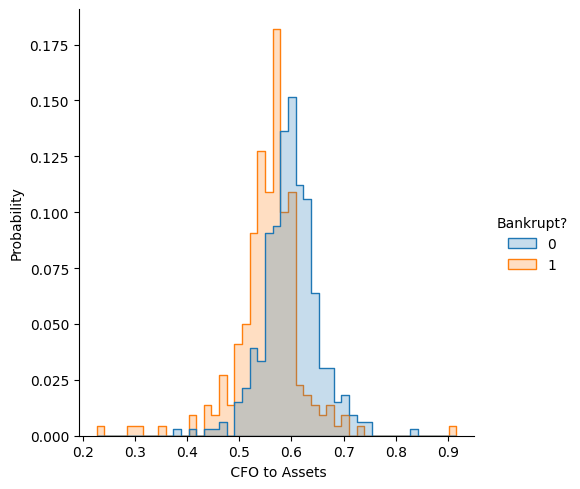

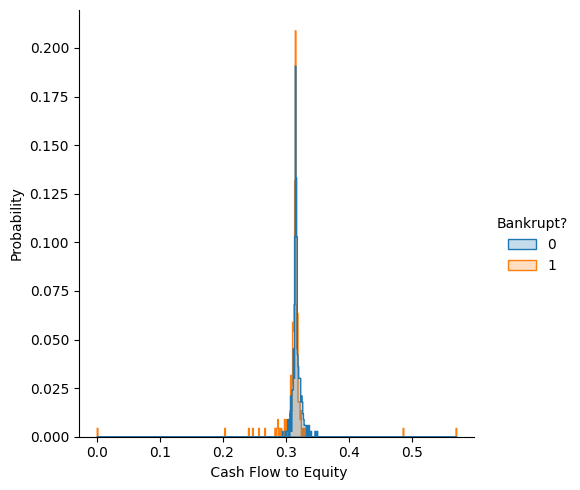

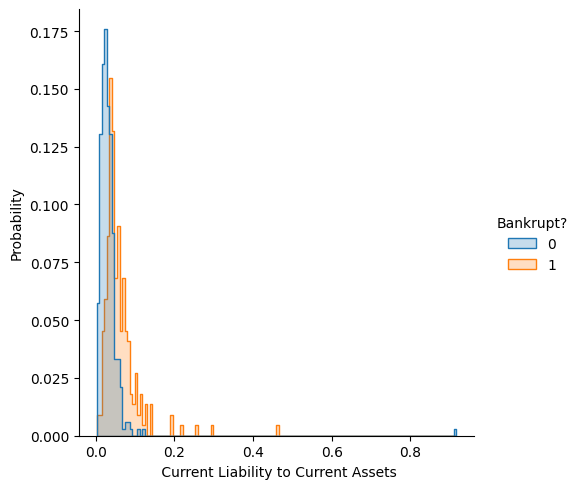

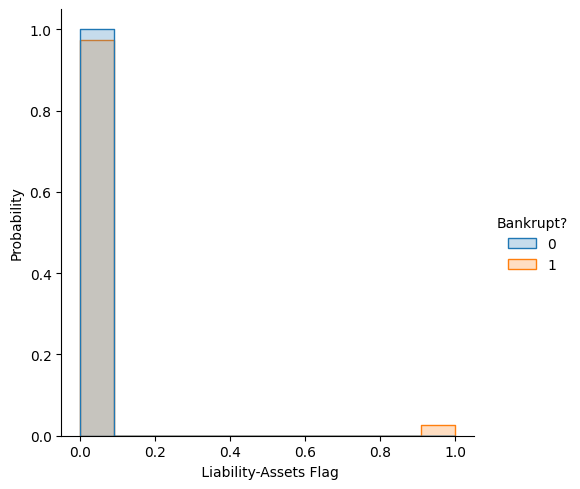

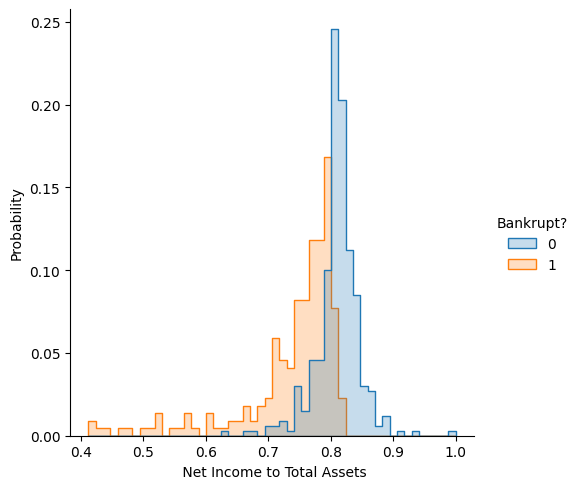

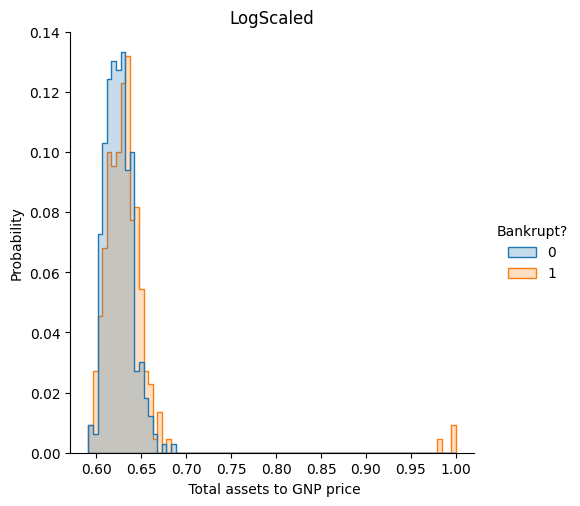

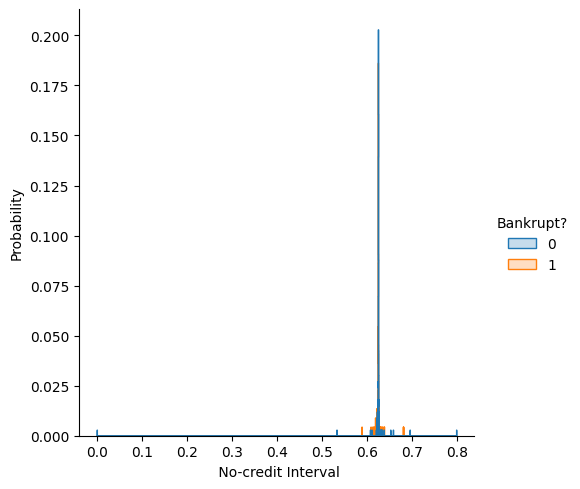

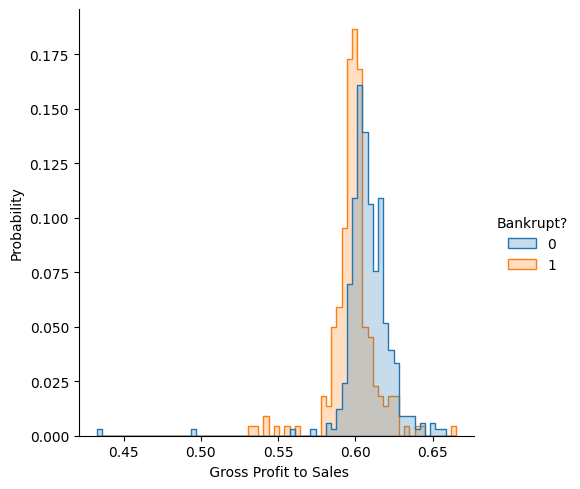

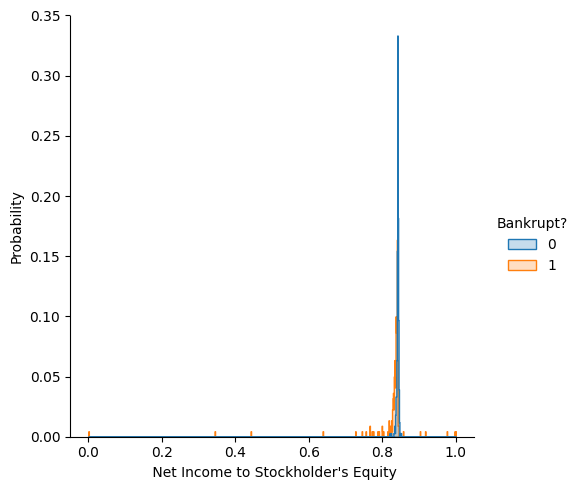

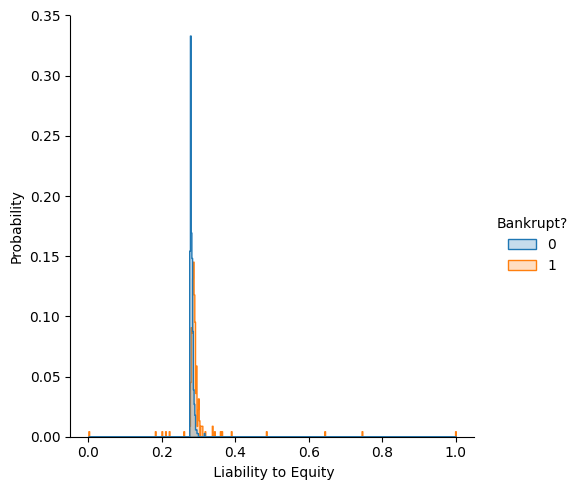

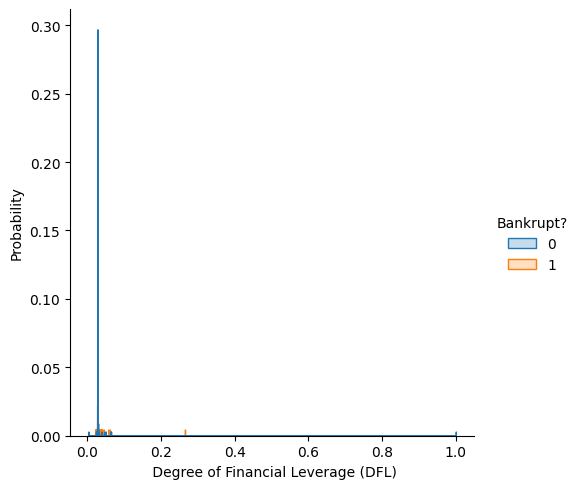

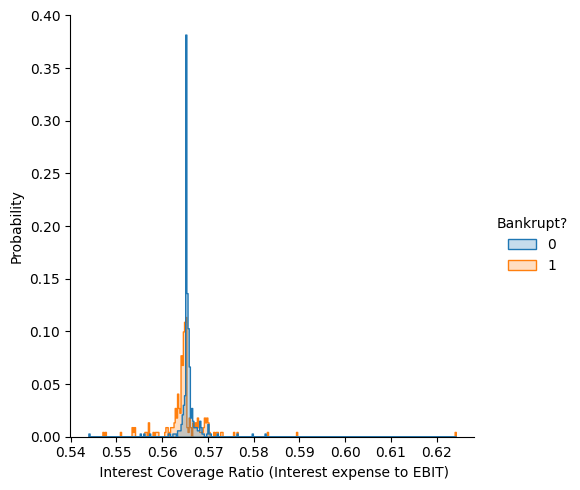

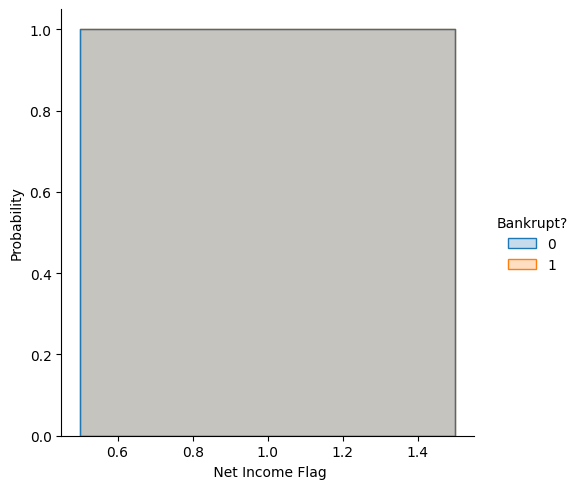

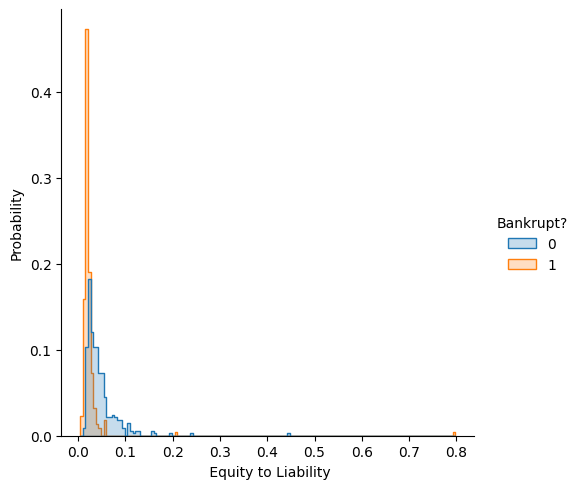

In [47]:
for column in balancedata.columns:
    if column!="Bankrupt?":
        if balancedata[column].max()>10:
            m=balancedata[column].max()
            sns.displot(data=balancedata,
                        x=balancedata[column].apply(lambda x: np.log(x**(np.log(np.e-1)/np.log(m))+1)),
                        hue="Bankrupt?", element="step", stat="probability",common_norm=False)
            plt.title("LogScaled")
        else:
            sns.displot(data=balancedata,
                        x=balancedata[column],
                        hue="Bankrupt?", element="step", stat="probability",common_norm=False)

Due to the nature of the variables, removing the outliers will reduce dramatically the data size. Let's remove the outliers using the quantile criteria:

\begin{equation}
Q_1- q · \ Q_{13}<{(X,y)} \leq Q_3+q · \ Q_{13}
\end{equation}

where

\begin{equation}
Q_{13}=Q_3-Q_1
\end{equation}

for q=3 (removing just the extreme outliers).

In [48]:
def outlier_remover(columnseries,q):
    Q1=columnseries.describe()["25%"]
    Q3=columnseries.describe()["75%"]
    Q13=Q3-Q1
    lowerbound=Q1-q*Q13
    upperbound=Q3+q*Q13
    newcolumnseries=columnseries[columnseries.between(lowerbound,upperbound)]
    return newcolumnseries

def outlier_clean(dataframe, exception_col=[],quo=1.5):
    if quo=="inf":
        newdataframe=dataframe
    else:
        newdataframe=pd.DataFrame()
        for columnname in dataframe.columns:
            if columnname not in exception_col:
                newdataframe[columnname]=outlier_remover(dataframe[columnname],q=quo)
            else:
                newdataframe[columnname]=dataframe[columnname]
        newdataframe=newdataframe.dropna()
    return newdataframe

cleandata=outlier_clean(balancedata, exception_col=["Bankrupt?"] ,quo=3)
cleandata.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,...,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.000000,96.0,96.000000
mean,0.197917,0.495306,0.550319,0.543370,0.607521,0.607513,0.999010,0.797437,0.809344,0.303522,...,0.803648,0.002912,0.623856,0.607519,0.840280,0.280679,0.026851,0.565324,1.0,0.034292
std,0.400520,0.048550,0.054286,0.049471,0.009179,0.009119,0.000117,0.000220,0.000199,0.000202,...,0.033312,0.003383,0.000595,0.009179,0.003432,0.004171,0.000165,0.000741,0.0,0.015454
min,0.000000,0.356018,0.403184,0.385674,0.580702,0.580702,0.998506,0.796642,0.808539,0.302892,...,0.694384,0.000318,0.621136,0.580698,0.828067,0.275871,0.026436,0.562609,1.0,0.014708
25%,0.000000,0.479635,0.541662,0.530971,0.601657,0.601684,0.998976,0.797411,0.809329,0.303490,...,0.800594,0.000951,0.623707,0.601656,0.840404,0.277859,0.026791,0.565158,1.0,0.022832
50%,0.000000,0.499927,0.559120,0.550083,0.606426,0.606426,0.999028,0.797476,0.809380,0.303531,...,0.810604,0.001751,0.623851,0.606424,0.841175,0.279421,0.026819,0.565286,1.0,0.030659
75%,0.000000,0.523290,0.577832,0.571444,0.612680,0.612680,0.999067,0.797542,0.809440,0.303584,...,0.822329,0.003289,0.624063,0.612678,0.841984,0.282364,0.026934,0.565758,1.0,0.040692
max,1.000000,0.595720,0.663541,0.650677,0.635192,0.635062,0.999350,0.797846,0.809715,0.304071,...,0.864391,0.020032,0.625927,0.635192,0.844734,0.296308,0.027410,0.567020,1.0,0.091584


The data size has reduced from 550 samples to just 90. We have to use the full balanced dataset to machine learn it.

## 4. Data learning

### Methodology

Using first the balanced data with the logarithmic transformation:
1) Split the data into k+1 sets. Then use the first k sets to apply a k-fold cross validation evaluation with F1-Score as the evaluation score with several algorithms with different hyperparameters. In this case, we will use k=5.

2) Get also the Accuracy, the Matthews Correlation Coefficient and the F2-Score of the best algorithms.

3) Use the remaining set to test the best algorithms found with the KFCV and also get the scores listed in 2).

4) Finally use the discarded negatives to do another test to the algorithms and get the accuracy, which is the only useful score since all the real outputs are negative so there will be just true negatives and false positives.

Then we repeat the same steps for the data set without the logarithmic transformation and finally we compare the results.

In [49]:
learndata=balancedata
finalresults=[]

### Data with logarithmic transformation

In [50]:
data_col=list(learndata.columns)
y_col=data_col.pop(data_col.index("Bankrupt?"))
X_col=data_col

X_data=pd.DataFrame()
X_discardata=pd.DataFrame()
for col in X_col:
    maxv=learndata[col].max()
    if maxv>10:
        X_data[col]=learndata[col].apply(lambda x: np.log(x**(np.log(np.e-1)/np.log(maxv))+1))
        X_discardata[col]=discardata[col].apply(lambda x: np.log(x**(np.log(np.e-1)/np.log(maxv))+1))
    else:
        X_data[col]=learndata[col]
        X_discardata[col]=discardata[col]
y_data=learndata[y_col]
y_discardata=discardata[y_col]

# K value of K-Fold CV assignation.

k=5
r=29

# Split into CV Training data and Testing data. We choose the test size to be equal to the validation size of our K-Fold CV.
# For doing so, we split the data into K+1 pieces and we use the first K pieces to K-Fold CV and the left one for final testing.

X_train, X_test, y_train, y_test = train_test_split(X_data,y_data,test_size=1/(k+1), random_state=r)
X_discarded, y_discarded = X_discardata.values, y_discardata.values

# Standard scaling of the input data X.

Xscaler=StandardScaler()
Xscaler.fit(X_train)
X_train=Xscaler.transform(X_train)
X_test=Xscaler.transform(X_test)
X_discarded=Xscaler.transform(X_discarded)

# Creation of the variables we will use to store the evaluation results for each algorythm.

modelScore_train={}
modelScore_test={}
modelScore_discarded={}
modelScore_KFCV={}
model_KFCV={}

modelConfussionMatrix_train={}
modelConfussionMatrix_test={}
modelConfussionMatrix_discarded={}

bankruptevents_train=pd.DataFrame()
bankruptevents_test=pd.DataFrame()
bankruptevents_discarded=pd.DataFrame()
bankruptevents_train["Bankrupt?"]=y_train
bankruptevents_test["Bankrupt?"]=y_test
bankruptevents_discarded["Bankrupt?"]=y_discarded

# Scorers setup and F1 assignation as the evaluation score.
scorersCV={"Acc": make_scorer(accuracy_score),
           "MCC": make_scorer(matthews_corrcoef),
           "F1": make_scorer(fbeta_score, beta=1),
           "F2": make_scorer(fbeta_score, beta=2)}
scorerCVkey="F1"

# Definition of the algorythm evaluation function.

def tuned_model(model, param_grid, modelname, results):
    tuner=GridSearchCV(model,param_grid=param_grid,scoring=scorersCV,cv=k,refit=scorerCVkey)
    tuner.fit(X_train,y_train)
    best_model=tuner.best_estimator_
    best_params=tuner.best_params_
    model_KFCV[modelname]=best_model
    print(f"Best model: {best_model}")

    modelScore_KFCV[modelname]={}
    resultcols=['rank_test_'+scorerCVkey]
    resultsdata=pd.DataFrame(tuner.cv_results_)
    for paramkey in param_grid:
        paramcolname="param_"+paramkey
        resultcols.append(paramkey)
        resultsdata=resultsdata.rename(columns={paramcolname:paramkey})

    for i in range(0,k):
        old_split_score_name="split%s_test_%s" % (i,scorerCVkey)
        new_split_score_name="s%s_%s" % (i,scorerCVkey)
        resultsdata=resultsdata.rename(columns={old_split_score_name: new_split_score_name})
        resultcols.append(new_split_score_name)

    for scorerkey in scorersCV:
        old_mean_score_name="mean_test_"+scorerkey
        new_mean_score_name="mean_"+scorerkey
        resultsdata=resultsdata.rename(columns={old_mean_score_name: new_mean_score_name})
        resultcols.append(new_mean_score_name)

        best_row=resultsdata[resultsdata["params"]==best_params]
        modelScore_KFCV[modelname][scorerkey]=round(best_row[new_mean_score_name].values[0],3)

    if results==True: print(resultsdata[resultcols].sort_values(by=resultcols[0]).round(3))

    return best_model

def plot_confusion_matrix(confusion_matrix,model_name):
    ax=plt.axes()
    confusionmatrix=sns.heatmap(data=confusion_matrix,annot=True,ax=ax)
    ax.set_title(model_name)
    plt.show()

def execute_model(model,modelname):
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_test_pred=model.predict(X_test)
    y_discarded_pred=model.predict(X_discarded)
    bankruptevents_train[modelname]=y_train_pred
    bankruptevents_test[modelname]=y_test_pred
    bankruptevents_discarded[modelname]=y_discarded_pred
    modelScore_train[modelname]={}
    modelScore_test[modelname]={}
    modelScore_discarded[modelname]={}
    for scorerkey in scorersCV:
        scorermaker=scorersCV[scorerkey]
        scorer=scorermaker._score_func
        scorerparams=scorermaker._kwargs
        modelScore_train[modelname][scorerkey]=round(scorer(y_train,y_train_pred,**scorermaker._kwargs) , 3)
        modelScore_test[modelname][scorerkey]=round(scorer(y_test,y_test_pred,**scorermaker._kwargs) , 3)
        modelScore_discarded[modelname][scorerkey]=round(scorer(y_discarded,y_discarded_pred,**scorermaker._kwargs) , 3)
    modelConfussionMatrix_train[modelname]=confusion_matrix(y_train,y_train_pred,labels=[0, 1],normalize="true")
    modelConfussionMatrix_test[modelname]=confusion_matrix(y_test,y_test_pred,labels=[0, 1],normalize="true")
    modelConfussionMatrix_discarded[modelname]=confusion_matrix(y_discarded,y_discarded_pred,labels=[0, 1],normalize="true")

def eval_model(model_func,model_pgrid, model_name, results_info=False):
    model=tuned_model(model=model_func, param_grid=model_pgrid, modelname=model_name, results=results_info)
    execute_model(model,model_name)

#### Logistic Regression

In [51]:
LogitRegr_params={"C":[1,0.5,0.1,0.01],
                  "solver":["lbfgs", "liblinear"]}
eval_model(LogisticRegression(),LogitRegr_params,"Logistic Regr.",True)

Best model: LogisticRegression(C=0.01, solver='liblinear')
   rank_test_F1     C     solver  s0_F1  s1_F1  s2_F1  s3_F1  s4_F1  mean_Acc  \
7             1  0.01  liblinear  0.842  0.790  0.872  0.872  0.842     0.867   
4             2  0.10      lbfgs  0.877  0.757  0.822  0.861  0.817     0.862   
5             3  0.10  liblinear  0.880  0.753  0.816  0.861  0.806     0.856   
2             4  0.50      lbfgs  0.877  0.732  0.833  0.829  0.817     0.858   
3             5  0.50  liblinear  0.877  0.722  0.817  0.845  0.817     0.856   
1             6  1.00  liblinear  0.861  0.730  0.817  0.806  0.817     0.847   
0             7  1.00      lbfgs  0.861  0.722  0.817  0.806  0.817     0.847   
6             8  0.01      lbfgs  0.829  0.696  0.865  0.794  0.817     0.847   

   mean_MCC  mean_F1  mean_F2  
7     0.733    0.844    0.877  
4     0.713    0.827    0.825  
5     0.702    0.823    0.834  
2     0.702    0.818    0.809  
3     0.698    0.816    0.808  
1     0.680    0.80

#### Stochastic Gradient Descend Classifier

In [52]:
SGDClf_params={"alpha":[0.1,0.05,0.01,0.005],
               "loss":["hinge","log","modified_huber"]}
eval_model(SGDClassifier(),SGDClf_params,"Stochastic Gradient Descend Clf.",True)

Best model: SGDClassifier(alpha=0.1)
    rank_test_F1  alpha            loss  s0_F1  s1_F1  s2_F1  s3_F1  s4_F1  \
0              1  0.100           hinge  0.861  0.740  0.817  0.861  0.817   
2              2  0.100  modified_huber  0.845  0.740  0.833  0.812  0.829   
9              3  0.005           hinge  0.889  0.727  0.806  0.794  0.838   
3              4  0.050           hinge  0.841  0.740  0.822  0.845  0.789   
5              5  0.050  modified_huber  0.861  0.722  0.822  0.800  0.817   
6              6  0.010           hinge  0.861  0.704  0.833  0.783  0.822   
8              7  0.010  modified_huber  0.805  0.684  0.771  0.827  0.825   
11             8  0.005  modified_huber  0.822  0.675  0.833  0.800  0.767   
7              9  0.010             log    NaN    NaN    NaN    NaN    NaN   
4              9  0.050             log    NaN    NaN    NaN    NaN    NaN   
1              9  0.100             log    NaN    NaN    NaN    NaN    NaN   
10             9  0.005    

#### Decision Tree Classifier

In [53]:
DTClf_params={"ccp_alpha":[0,0.05,0.001],
              "criterion":["gini", "entropy"],
              "max_features":[None,"auto", "sqrt", "log2"]}
eval_model(DecisionTreeClassifier(), DTClf_params, "Decision Tree Clf.", True)

Best model: DecisionTreeClassifier(ccp_alpha=0.05, criterion='entropy')
    rank_test_F1  ccp_alpha criterion max_features  s0_F1  s1_F1  s2_F1  \
12             1      0.050   entropy         None  0.816  0.704  0.821   
23             2      0.001   entropy         log2  0.877  0.684  0.812   
22             3      0.001   entropy         sqrt  0.817  0.712  0.800   
16             4      0.001      gini         None  0.849  0.720  0.714   
8              5      0.050      gini         None  0.816  0.709  0.688   
20             6      0.001   entropy         None  0.811  0.667  0.784   
7              7      0.000   entropy         log2  0.747  0.711  0.811   
3              8      0.000      gini         log2  0.750  0.684  0.773   
10             9      0.050      gini         sqrt  0.744  0.716  0.738   
2             10      0.000      gini         sqrt  0.785  0.716  0.765   
11            11      0.050      gini         log2  0.753  0.725  0.782   
4             12      0.000 

#### Multi Layer Perceptron Classifier

In [54]:
MLPClf_params={"alpha":[0.05,0.01,0.001,0.0001],
               "activation":["tanh","relu"],
               "hidden_layer_sizes":[20,50],
               "learning_rate":["constant","adaptive"]}
eval_model(MLPClassifier(), MLPClf_params, "Multi-Layer Perceptron Clf.", True)

Best model: MLPClassifier(alpha=0.01, hidden_layer_sizes=50, learning_rate='adaptive')
    rank_test_F1  alpha activation  hidden_layer_sizes learning_rate  s0_F1  \
23             1  0.010       relu                  50      adaptive  0.845   
4              2  0.010       tanh                  20      constant  0.868   
0              3  0.050       tanh                  20      constant  0.880   
31             4  0.000       relu                  50      adaptive  0.822   
16             5  0.050       relu                  20      constant  0.853   
18             6  0.050       relu                  50      constant  0.833   
28             7  0.000       relu                  20      constant  0.873   
29             8  0.000       relu                  20      adaptive  0.841   
21             9  0.010       relu                  20      adaptive  0.816   
20            10  0.010       relu                  20      constant  0.849   
14            11  0.000       tanh          

#### Random Forest Classifier

In [55]:
RFClf_params={"ccp_alpha":[0.01,0.03,0.05,0.005],
              "criterion":["gini", "entropy"],
              "n_estimators":[1,2,5,10]}
eval_model(RandomForestClassifier(), RFClf_params, "Random Forest Clf.", True)

Best model: RandomForestClassifier(ccp_alpha=0.01, n_estimators=10)
    rank_test_F1  ccp_alpha criterion  n_estimators  s0_F1  s1_F1  s2_F1  \
3              1      0.010      gini            10  0.811  0.785  0.838   
26             2      0.005      gini             5  0.861  0.785  0.842   
6              3      0.010   entropy             5  0.817  0.763  0.817   
23             4      0.050   entropy            10  0.833  0.753  0.831   
22             5      0.050   entropy             5  0.811  0.750  0.853   
12             6      0.030   entropy             1  0.846  0.771  0.827   
14             7      0.030   entropy             5  0.865  0.753  0.789   
7              8      0.010   entropy            10  0.800  0.704  0.861   
2              9      0.010      gini             5  0.838  0.718  0.838   
9             10      0.030      gini             2  0.795  0.677  0.857   
11            11      0.030      gini            10  0.811  0.727  0.827   
19            12    

#### SCORES

In [56]:
print("Score (%d-fold CV Train data)" % k)
for key in modelScore_KFCV:
    print("%s: %s" % (key, modelScore_KFCV[key]))
print("\n")
print("Score (Test data)")
for key in modelScore_test:
    print("{}: {}".format(key,modelScore_test[key]))
print("\n")
print("Accuracy (Discarded data)")
for key in modelScore_discarded:
    print("{}: {}".format(key,modelScore_discarded[key]["Acc"]))

for key in modelScore_KFCV:
    row={}
    row["Algorithm"]=key
    row["LogTrans"]=1
    row["F1-Score"]=modelScore_KFCV[key]["F1"]
    row["Accuracy"]=modelScore_KFCV[key]["Acc"]
    row["MCC"]=modelScore_KFCV[key]["MCC"]
    row["F2-Score"]=modelScore_KFCV[key]["F2"]
    row["Discarded Accuracy"]=modelScore_discarded[key]["Acc"]
    exists=[]
    for row_ in finalresults:
        existsbool=False
        if (row_["Algorithm"]==row["Algorithm"]) and (row_["LogTrans"]==row["LogTrans"]): existsbool=True
        exists.append(existsbool)
    if True in exists:
        finalresults[exists.index(True)]=row
    else:
        finalresults.append(row)

Score (5-fold CV Train data)
Logistic Regr.: {'Acc': np.float64(0.867), 'MCC': np.float64(0.733), 'F1': np.float64(0.844), 'F2': np.float64(0.877)}
Stochastic Gradient Descend Clf.: {'Acc': np.float64(0.858), 'MCC': np.float64(0.703), 'F1': np.float64(0.819), 'F2': np.float64(0.813)}
Decision Tree Clf.: {'Acc': np.float64(0.834), 'MCC': np.float64(0.656), 'F1': np.float64(0.788), 'F2': np.float64(0.783)}
Multi-Layer Perceptron Clf.: {'Acc': np.float64(0.856), 'MCC': np.float64(0.703), 'F1': np.float64(0.823), 'F2': np.float64(0.833)}
Random Forest Clf.: {'Acc': np.float64(0.854), 'MCC': np.float64(0.697), 'F1': np.float64(0.817), 'F2': np.float64(0.818)}


Score (Test data)
Logistic Regr.: {'Acc': 0.815, 'MCC': np.float64(0.621), 'F1': 0.779, 'F2': 0.785}
Stochastic Gradient Descend Clf.: {'Acc': 0.804, 'MCC': np.float64(0.596), 'F1': 0.763, 'F2': 0.763}
Decision Tree Clf.: {'Acc': 0.772, 'MCC': np.float64(0.525), 'F1': 0.712, 'F2': 0.695}
Multi-Layer Perceptron Clf.: {'Acc': 0.793, 'M

#### TEST SET PREDICTIONS OVERVIEW (SOME PREDICTIONS + NORMALIZED CONFUSSION MATRICES)

In [57]:
bankruptevents_test.head(50)

,Bankrupt?,Logistic Regr.,Stochastic Gradient Descend Clf.,Decision Tree Clf.,Multi-Layer Perceptron Clf.,Random Forest Clf.
3801,0,0,0,0,0,0
1188,0,0,0,0,0,0
3183,1,1,1,1,1,1
186,1,1,1,1,1,1
2148,1,1,1,1,1,1
1247,1,1,1,1,0,1
167,0,0,0,0,0,0
1754,1,1,1,0,1,1
3054,0,0,0,0,0,0
869,1,1,1,0,1,0


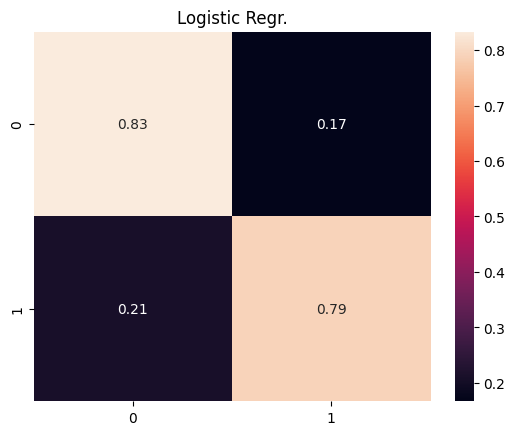

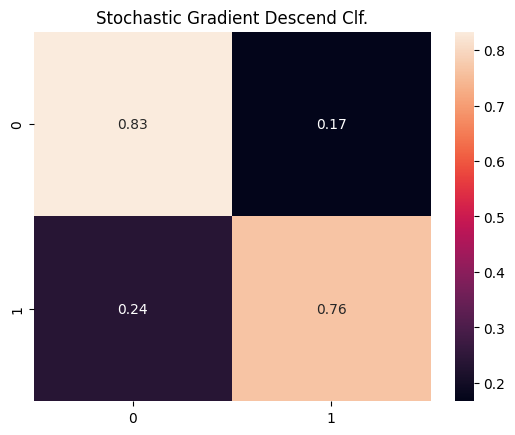

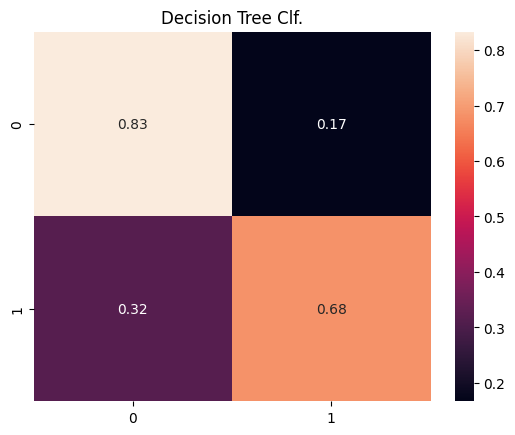

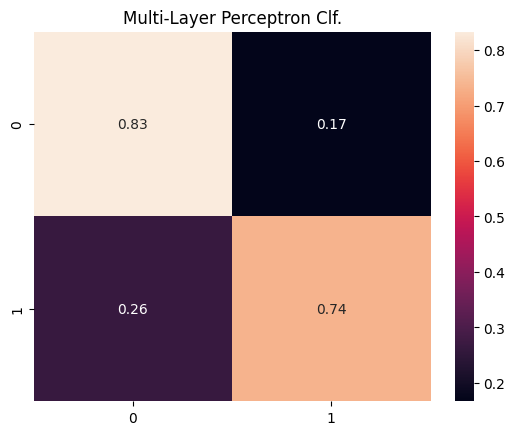

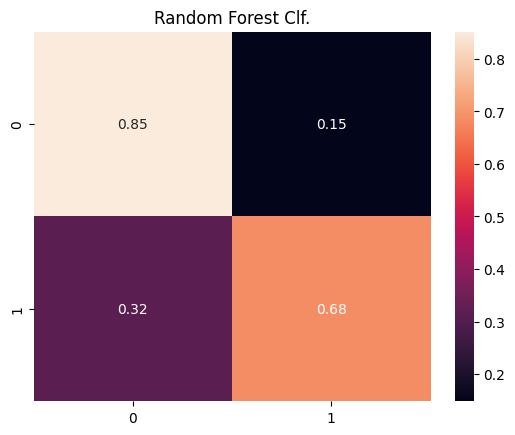

In [58]:
for modelname in bankruptevents_test.columns:
    if modelname!="Bankrupt?":
       c_matrix=modelConfussionMatrix_test[modelname]
       c_matrix_plot=plot_confusion_matrix(c_matrix,modelname)

### Data without logarithmic transformation

In [59]:
data_col=list(learndata.columns)
y_col=data_col.pop(data_col.index("Bankrupt?"))
X_col=data_col

X_data=pd.DataFrame()
X_discardata=pd.DataFrame()
for col in X_col:
    X_data[col]=learndata[col]
    X_discardata[col]=discardata[col]
y_data=learndata[y_col]
y_discardata=discardata[y_col]

# K value of K-Fold CV assignation.

k=5
r=29

# Split into CV Training data and Testing data. We choose the test size to be equal to the validation size of our K-Fold CV.
# For doing so, we split the data into K+1 pieces and we use the first K pieces to K-Fold CV and the left one for final testing.

X_train, X_test, y_train, y_test = train_test_split(X_data,y_data,test_size=1/(k+1), random_state=r)
X_discarded, y_discarded = X_discardata.values, y_discardata.values

# Standard scaling of the input data X.

Xscaler=StandardScaler()
Xscaler.fit(X_train)
X_train=Xscaler.transform(X_train)
X_test=Xscaler.transform(X_test)
X_discarded=Xscaler.transform(X_discarded)

# Creation of the variables we will use to store the evaluation results for each algorythm.

modelScore_train={}
modelScore_test={}
modelScore_discarded={}
modelScore_KFCV={}
model_KFCV={}

modelConfussionMatrix_train={}
modelConfussionMatrix_test={}
modelConfussionMatrix_discarded={}

bankruptevents_train=pd.DataFrame()
bankruptevents_test=pd.DataFrame()
bankruptevents_discarded=pd.DataFrame()
bankruptevents_train["Bankrupt?"]=y_train
bankruptevents_test["Bankrupt?"]=y_test
bankruptevents_discarded["Bankrupt?"]=y_discarded


#### Logistic Regression

In [60]:
eval_model(LogisticRegression(),LogitRegr_params,"Logistic Regr.",True)

Best model: LogisticRegression(C=0.1, solver='liblinear')
   rank_test_F1     C     solver  s0_F1  s1_F1  s2_F1  s3_F1  s4_F1  mean_Acc  \
5             1  0.10  liblinear  0.811  0.763  0.892  0.889  0.838     0.869   
7             2  0.01  liblinear  0.842  0.779  0.886  0.827  0.842     0.862   
4             3  0.10      lbfgs  0.822  0.757  0.861  0.901  0.806     0.865   
2             4  0.50      lbfgs  0.811  0.753  0.877  0.845  0.822     0.856   
0             5  1.00      lbfgs  0.827  0.737  0.849  0.857  0.833     0.856   
1             6  1.00  liblinear  0.805  0.753  0.849  0.857  0.833     0.854   
3             7  0.50  liblinear  0.800  0.753  0.877  0.845  0.822     0.854   
6             8  0.01      lbfgs  0.795  0.706  0.829  0.776  0.806     0.834   

   mean_MCC  mean_F1  mean_F2  
5     0.729    0.839    0.846  
7     0.720    0.835    0.861  
4     0.718    0.829    0.826  
2     0.701    0.822    0.826  
0     0.701    0.821    0.823  
1     0.698    0.820

#### Stochastic Gradient Descend Classifier

In [61]:
eval_model(SGDClassifier(),SGDClf_params,"Stochastic Gradient Descend Clf.",True)

Best model: SGDClassifier(alpha=0.1)
    rank_test_F1  alpha            loss  s0_F1  s1_F1  s2_F1  s3_F1  s4_F1  \
0              1  0.100           hinge  0.833  0.778  0.794  0.841  0.849   
2              2  0.100  modified_huber  0.778  0.757  0.861  0.845  0.822   
3              3  0.050           hinge  0.817  0.767  0.812  0.806  0.827   
6              4  0.010           hinge  0.833  0.737  0.833  0.812  0.811   
5              5  0.050  modified_huber  0.778  0.747  0.806  0.845  0.811   
9              6  0.005           hinge  0.817  0.744  0.771  0.800  0.816   
8              7  0.010  modified_huber  0.761  0.737  0.806  0.827  0.761   
11             8  0.005  modified_huber  0.778  0.730  0.767  0.833  0.779   
7              9  0.010             log    NaN    NaN    NaN    NaN    NaN   
4              9  0.050             log    NaN    NaN    NaN    NaN    NaN   
1              9  0.100             log    NaN    NaN    NaN    NaN    NaN   
10             9  0.005    

#### Decision Tree Classifier

In [62]:
eval_model(DecisionTreeClassifier(), DTClf_params, "Decision Tree Clf.", True)

Best model: DecisionTreeClassifier(ccp_alpha=0.05, max_features='sqrt')
    rank_test_F1  ccp_alpha criterion max_features  s0_F1  s1_F1  s2_F1  \
10             1      0.050      gini         sqrt  0.795  0.779  0.821   
12             2      0.050   entropy         None  0.816  0.704  0.805   
15             3      0.050   entropy         log2  0.794  0.810  0.744   
14             4      0.050   entropy         sqrt  0.827  0.738  0.727   
7              5      0.000   entropy         log2  0.753  0.750  0.750   
11             6      0.050      gini         log2  0.753  0.709  0.805   
8              7      0.050      gini         None  0.816  0.709  0.688   
0              8      0.000      gini         None  0.806  0.718  0.685   
4              9      0.000   entropy         None  0.735  0.714  0.722   
18            10      0.001      gini         sqrt  0.773  0.729  0.709   
20            11      0.001   entropy         None  0.727  0.696  0.737   
6             12      0.000 

#### Multi Layer Perceptron Classifier

In [63]:
eval_model(MLPClassifier(), MLPClf_params, "Multi-Layer Perceptron Clf.", True)

Best model: MLPClassifier(activation='tanh', hidden_layer_sizes=20,
              learning_rate='adaptive')
    rank_test_F1  alpha activation  hidden_layer_sizes learning_rate  s0_F1  \
13             1  0.000       tanh                  20      adaptive  0.795   
29             2  0.000       relu                  20      adaptive  0.806   
1              3  0.050       tanh                  20      adaptive  0.822   
2              4  0.050       tanh                  50      constant  0.789   
0              5  0.050       tanh                  20      constant  0.784   
4              6  0.010       tanh                  20      constant  0.827   
5              7  0.010       tanh                  20      adaptive  0.779   
8              8  0.001       tanh                  20      constant  0.773   
17             9  0.050       relu                  20      adaptive  0.822   
12            10  0.000       tanh                  20      constant  0.821   
9             11  0.001

#### Random Forest Classifier

In [64]:
eval_model(RandomForestClassifier(), RFClf_params, "Random Forest Clf.", True)

Best model: RandomForestClassifier(ccp_alpha=0.005, n_estimators=10)
    rank_test_F1  ccp_alpha criterion  n_estimators  s0_F1  s1_F1  s2_F1  \
27             1      0.005      gini            10  0.822  0.759  0.822   
23             2      0.050   entropy            10  0.838  0.700  0.850   
22             3      0.050   entropy             5  0.838  0.790  0.795   
1              4      0.010      gini             2  0.853  0.747  0.805   
7              5      0.010   entropy            10  0.853  0.753  0.811   
3              6      0.010      gini            10  0.816  0.720  0.822   
2              7      0.010      gini             5  0.849  0.750  0.846   
11             8      0.030      gini            10  0.822  0.763  0.816   
31             9      0.005   entropy            10  0.861  0.759  0.743   
15            10      0.030   entropy            10  0.795  0.727  0.800   
6             11      0.010   entropy             5  0.845  0.734  0.827   
10            12   

#### SCORES

In [65]:
print("Score (%d-fold CV Train data)" % k)
for key in modelScore_KFCV:
    print("%s: %s" % (key, modelScore_KFCV[key]))
print("\n")
print("Score (Test data)")
for key in modelScore_test:
    print("{}: {}".format(key,modelScore_test[key]))
print("\n")
print("Accuracy (Discarded data)")
for key in modelScore_discarded:
    print("{}: {}".format(key,modelScore_discarded[key]["Acc"]))

for key in modelScore_KFCV:
    row={}
    row["Algorithm"]=key
    row["LogTrans"]=0
    row["F1-Score"]=modelScore_KFCV[key]["F1"]
    row["Accuracy"]=modelScore_KFCV[key]["Acc"]
    row["MCC"]=modelScore_KFCV[key]["MCC"]
    row["F2-Score"]=modelScore_KFCV[key]["F2"]
    row["Discarded Accuracy"]=modelScore_discarded[key]["Acc"]
    exists=[]
    for row_ in finalresults:
        existsbool=False
        if (row_["Algorithm"]==row["Algorithm"]) and (row_["LogTrans"]==row["LogTrans"]): existsbool=True
        exists.append(existsbool)
    if True in exists:
        finalresults[exists.index(True)]=row
    else:
        finalresults.append(row)

Score (5-fold CV Train data)
Logistic Regr.: {'Acc': np.float64(0.869), 'MCC': np.float64(0.729), 'F1': np.float64(0.839), 'F2': np.float64(0.846)}
Stochastic Gradient Descend Clf.: {'Acc': np.float64(0.86), 'MCC': np.float64(0.707), 'F1': np.float64(0.819), 'F2': np.float64(0.806)}
Decision Tree Clf.: {'Acc': np.float64(0.838), 'MCC': np.float64(0.667), 'F1': np.float64(0.79), 'F2': np.float64(0.776)}
Multi-Layer Perceptron Clf.: {'Acc': np.float64(0.869), 'MCC': np.float64(0.731), 'F1': np.float64(0.84), 'F2': np.float64(0.853)}
Random Forest Clf.: {'Acc': np.float64(0.849), 'MCC': np.float64(0.688), 'F1': np.float64(0.814), 'F2': np.float64(0.82)}


Score (Test data)
Logistic Regr.: {'Acc': 0.793, 'MCC': np.float64(0.57), 'F1': 0.74, 'F2': 0.722}
Stochastic Gradient Descend Clf.: {'Acc': 0.761, 'MCC': np.float64(0.5), 'F1': 0.686, 'F2': 0.652}
Decision Tree Clf.: {'Acc': 0.804, 'MCC': np.float64(0.6), 'F1': 0.769, 'F2': 0.781}
Multi-Layer Perceptron Clf.: {'Acc': 0.75, 'MCC': np.flo

#### TEST SET PREDICTIONS OVERVIEW (SOME PREDICTIONS + NORMALIZED CONFUSSION MATRICES)

In [66]:
bankruptevents_test.head(50)

,Bankrupt?,Logistic Regr.,Stochastic Gradient Descend Clf.,Decision Tree Clf.,Multi-Layer Perceptron Clf.,Random Forest Clf.
3801,0,0,0,0,0,0
1188,0,0,0,1,0,1
3183,1,1,1,1,1,1
186,1,1,0,1,1,1
2148,1,1,1,1,1,1
1247,1,1,1,1,1,1
167,0,0,0,0,0,0
1754,1,1,1,1,1,1
3054,0,0,0,0,0,0
869,1,0,0,0,0,0


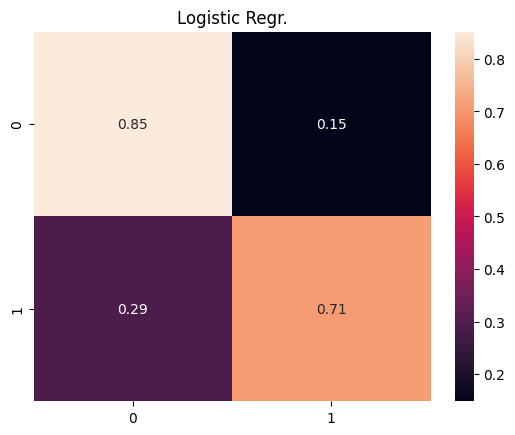

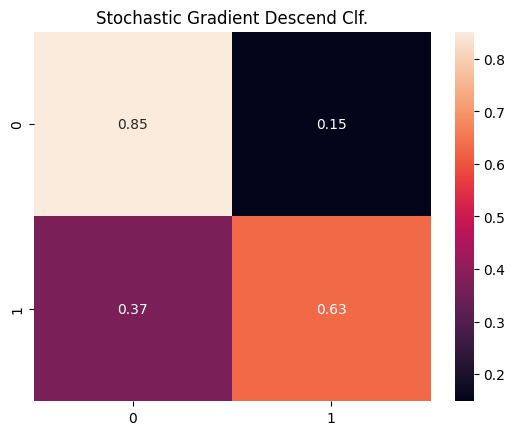

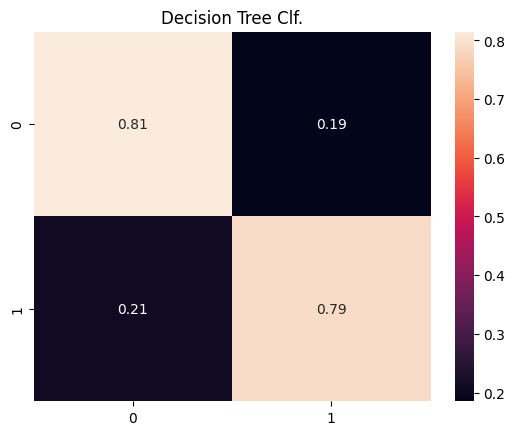

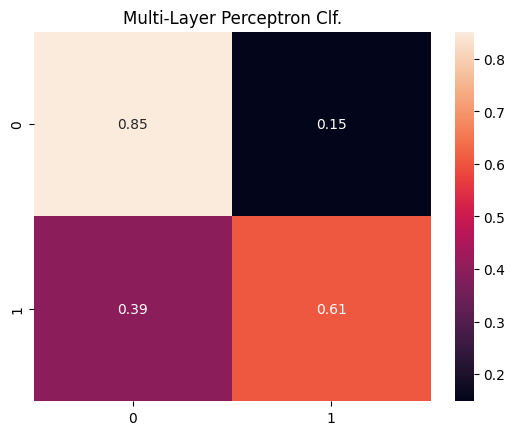

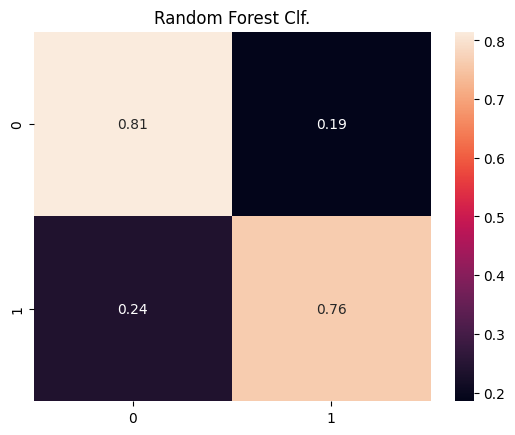

In [67]:
for modelname in bankruptevents_test.columns:
    if modelname!="Bankrupt?":
       c_matrix=modelConfussionMatrix_test[modelname]
       c_matrix_plot=plot_confusion_matrix(c_matrix,modelname)

### FINAL RESULTS

Now the scores of the algorithms applied to both logtransformed and non transformed datasets will be shown, ordered from thw best to the worst F1-Score.

In [68]:
pd.DataFrame(finalresults).sort_values(by="F1-Score",ascending=False)

,Algorithm,LogTrans,F1-Score,Accuracy,MCC,F2-Score,Discarded Accuracy
0,Logistic Regr.,1,0.844,0.867,0.733,0.877,0.859
8,Multi-Layer Perceptron Clf.,0,0.840,0.869,0.731,0.853,0.874
5,Logistic Regr.,0,0.839,0.869,0.729,0.846,0.878
3,Multi-Layer Perceptron Clf.,1,0.823,0.856,0.703,0.833,0.875
1,Stochastic Gradient Descend Clf.,1,0.819,0.858,0.703,0.813,0.891
6,Stochastic Gradient Descend Clf.,0,0.819,0.860,0.707,0.806,0.900
4,Random Forest Clf.,1,0.817,0.854,0.697,0.818,0.901
9,Random Forest Clf.,0,0.814,0.849,0.688,0.820,0.885
7,Decision Tree Clf.,0,0.790,0.838,0.667,0.776,0.765
2,Decision Tree Clf.,1,0.788,0.834,0.656,0.783,0.856


The logarithmic transformation has improved the performance of the algorithms slightly.

In general the best algorithms with the dataset with the logarithmic transformation show a F1-Score well above 0.8, which it's not ideal, but it's not bad at all.